In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

print("Jupyter Working")

Jupyter Working


In [2]:
import pymysql
from sqlalchemy import create_engine 
from sqlalchemy.engine import URL
url = URL.create(
    drivername =  'mysql+pymysql',
    username = 'root',
    password = '@Great00',
    host = 'localhost',
    port = 3306,
    database = 'olist_project'    
)

engine = create_engine(url)
     

print('Connnection successful')

Connnection successful


In [3]:
query = "SHOW TABLES"
df = pd.read_sql(query, engine)
df


,Tables_in_olist_project
0,category
1,customers
2,geolocation
3,order_items
4,order_payment
5,orders
6,products
7,review
8,sellers


## PHASE 1 - CLEANING AND VALIDATING EACH TABLE 

In [4]:
query = '''SELECT *
FROM customers'''
df = pd.read_sql(query, engine)
print(df.info())
print(df.isna().sum())
duplicates = df.duplicated()
print(df[duplicates])
# filt = df['customer_unique_id'] == 'b6c083700ca8c135ba9f0f132930d4e8'
# print(df[filt])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
Empty DataFrame
Columns: [customer_id, customer_unique_id, customer_zip_code_prefix, customer_city, customer_state]
Index: []


Customers 
---------
Rows : 99441
columns : 5
Missing values : None
Duplicate Rows : None
Duplicate Primary Key : customer_unique_id
Observations : customer_unique_id represents unique customers and  customer_id is the unique id given to every customer on every order.

In [5]:
query = '''SELECT *
FROM geolocation'''
df = pd.read_sql(query, engine)
print(df.info())
print(df.isna().sum())
duplicates = df.duplicated().sum()
print(duplicates)
df.drop_duplicates(inplace = True)
print(df.duplicated().sum())
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  object 
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), object(3)
memory usage: 38.2+ MB
None
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64
261831
0
<class 'pandas.core.frame.DataFrame'>
Index: 738332 entries, 0 to 1000161
Data columns (total 5 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  

## Geolocation
---------
Rows : 738327
columns : 5
Missing values : None
Duplicate Rows : 261836
Duplicate Primary Key : Not any particular Key
Observations : There are a lot of duplicate pin codes but each of them have different latitude and longitude values.

In [6]:
query = '''SELECT *
FROM order_items'''
df = pd.read_sql(query, engine)
print(df.info())
duplicates = df.duplicated(subset =['order_id','order_item_id'], keep = False)
print(df[duplicates])
print(df.isna().sum())
# NO DUPLICATE VALUES

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB
None
Empty DataFrame
Columns: [order_id, order_item_id, product_id, seller_id, shipping_limit_date, price, freight_value]
Index: []
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


Order_items
---------
Rows :112650
columns : 7
Missing values : None
Duplicate Rows : None
Duplicate Primary Key : order_id and order_item_id
Observations : In this each row represents a single ordered item not not a single order so id someone orders two item together then there will be two rows for it with all the values identical but distinct order_item_id value.

In [7]:
query = '''SELECT *
FROM order_payment'''
df = pd.read_sql(query, engine)
print(df.info())
print(df.isna().sum())
duplicates = df.duplicated(subset = ['order_id', 'payment_sequential'])
print(df[duplicates])
# filt = df['order_id'] == '683bf306149bb869980b68d48a1bd6ab'
# print(df.loc[filt])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB
None
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64
Empty DataFrame
Columns: [order_id, payment_sequential, payment_type, payment_installments, payment_value]
Index: []


Order_payment
---------
Rows : 103886
columns : 5
Missing values : None
Duplicate Rows : None
Duplicate Primary Key : order_id, payment_sequential
Observations : In this table if a payment is done using two or more different modes than it has different rows for each mode with all the values identical but distinct payment_sequential value

In [8]:
query = '''SELECT *
FROM orders'''
df = pd.read_sql(query, engine)
print(df.info())
print(df.isna().sum())
duplicates = df.duplicated(subset = 'order_id').sum()
print(duplicates)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99441 non-null  object
 5   order_delivered_carrier_date   99441 non-null  object
 6   order_delivered_customer_date  99441 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None
order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estima

In [9]:
query = '''SELECT *
FROM products'''
df = pd.read_sql(query, engine)
print(df.info())
print(df.isna().sum())
duplicates = df.duplicated().sum()
print(duplicates)
# df.loc[df['product_category_name'] == 'perfumaria']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   product_id                  32951 non-null  object
 1   product_category            32951 non-null  object
 2   product_name_lenght         32951 non-null  int64 
 3   product_description_lenght  32951 non-null  int64 
 4   product_photos_qty          32951 non-null  int64 
 5   product_weight_g            32951 non-null  int64 
 6   product_length_cm           32951 non-null  int64 
 7   product_height_cm           32951 non-null  int64 
 8   product_width_cm            32951 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 2.3+ MB
None
product_id                    0
product_category              0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm            

Products
---------
Rows : 32951
columns : 9
Missing values : None
Duplicate Rows : None
Duplicate Primary Key : product_id
Observations : Here the key differentiator is product_id, there are duplicates if we check using others keys but they essentially don't mean duplicates.

In [10]:
query = '''SELECT *
FROM review'''
df = pd.read_sql(query, engine)
print(df.info())
print(df.isna().sum())
duplicates = df.duplicated().sum()
print(duplicates)
# df['review_id'].nunique()
filt = df['review_id'] == '3242cc306a9218d0377831e175d62fbf'
print(df[filt])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99223 entries, 0 to 99222
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99223 non-null  object
 1   order_id                 99223 non-null  object
 2   review_score             99223 non-null  int64 
 3   review_comment_title     99223 non-null  object
 4   review_comment_message   99223 non-null  object
 5   review_answer_timestamp  99223 non-null  object
 6   review_creation_date     99223 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB
None
review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_answer_timestamp    0
review_creation_date       0
dtype: int64
0
                             review_id                          order_id  \
1009  3242cc306a9218d0377831e175d62fbf  711246846695fa895c1776f0dd

Review
---------
Rows : 99224
columns : 7
Missing values : None
Duplicate Rows : None
Duplicate Primary Key : review_id, order_id
Observations :In this table there are duplicate tables when checked according to review_id but order_id is different in all of them which suggests that this dataset was probably designed with a one-review-to-many-orders relationship i.e. same review is passed to many orders that are done together.

In [11]:
query = '''SELECT *
FROM sellers'''
df = pd.read_sql(query, engine)
print(df.info())
print(df.isna().sum())
duplicates = df.duplicated().sum()
print(duplicates)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6190 entries, 0 to 6189
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               6190 non-null   object
 1   seller_zip_code_prefix  6190 non-null   int64 
 2   seller_city             6190 non-null   object
 3   seller_state            6190 non-null   object
dtypes: int64(1), object(3)
memory usage: 193.6+ KB
None
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64
3095


Sellers
---------
Rows : 3095
columns : 4
Missing values : None
Duplicate Rows : None
Duplicate Primary Key : seller_id
Observations : Here the key differentiator is seller_id.

## PHASE 2 - KPI DASHBOARD

In [12]:
query = '''SELECT SUM(payment_value) TOTAL_REVENUE
FROM order_payment OP
JOIN orders O
ON OP.order_id = O.order_id
where O.order_status = 'delivered' '''
df = pd.read_sql(query, engine)
rev = df['TOTAL_REVENUE']
round(rev)

0    15422462.0
Name: TOTAL_REVENUE, dtype: float64

Total Revenue = 15422462.0

In [13]:
query = '''SELECT COUNT( order_id) TOTAL_ORDER
FROM orders
where order_status = 'delivered';'''
df = pd.read_sql(query, engine)
Total_order = df['TOTAL_ORDER']
Total_order

0    96478
Name: TOTAL_ORDER, dtype: int64

Total Orders = 96478

In [14]:
query = '''SELECT COUNT(DISTINCT customer_unique_id) TOTAL_CUSTOMERS
FROM customers;'''
df = pd.read_sql(query, engine)
df
cus = df['TOTAL_CUSTOMERS']
cus

0    96096
Name: TOTAL_CUSTOMERS, dtype: int64

Total Customers = 96096

In [15]:
rev_per_cus = rev/cus
round(rev_per_cus)

0    160.0
dtype: float64

Revenue Per Customer = 160.0

In [16]:
query = '''SELECT AVG(PAYMENT_VALUE) AS AVG_ORDER_VALUE
FROM order_payment OP
JOIN orders O
ON OP.order_id = O.order_id
where O.order_status = 'delivered';'''
df = pd.read_sql(query, engine)
avg_order_value = df['AVG_ORDER_VALUE']
round(avg_order_value)

0    153.0
Name: AVG_ORDER_VALUE, dtype: float64

Average Order Value = 153.0

In [17]:
query = '''WITH DELIVERY_DURATION AS(
SELECT order_id, 
DATEDIFF(order_delivered_customer_date, order_approved_at) AS delivery_time,
TIMESTAMPDIFF(HOUR, order_approved_at, order_delivered_customer_date) as DELIVERY_HOURS
FROM ORDERS 
WHERE order_status = 'delivered')
SELECT sum(delivery_time)/COUNT(order_id) as Avg_delivery_days, 
sum(DELIVERY_HOURS)/COUNT(order_id) as Avg_delivery_hours
FROM DELIVERY_DURATION ;'''
df = pd.read_sql(query, engine)
round(df)

,Avg_delivery_days,Avg_delivery_hours
0,12.0,291.0


Average Delivery Days = 12
Average Delivery Hours = 291

In [18]:
query = '''WITH REPEAT_CUS AS(
SELECT customer_unique_id, count(order_id) as NO_OF_ORDERS
FROM orders O 
join customers C 
on O.customer_id = C.customer_id
where O.order_status = 'delivered'
group by customer_unique_id
order by NO_OF_ORDERS)
select COUNT(customer_unique_id) REPEAT_CUS, (SELECT COUNT(DISTINCT customer_unique_id)
from orders O 
join customers C 
on O.customer_id = C.customer_id
where O.order_status = 'delivered') TOTAL_CUS
FROM REPEAT_CUS
WHERE NO_OF_ORDERS > 1;'''
df = pd.read_sql(query, engine)
repeat_perc = df['REPEAT_CUS']/df['TOTAL_CUS']*100
print(f'{round(repeat_perc)}%')


0    3.0
dtype: float64%


## Phase 3 - Revenue Analysis

Repeat Customer Percentage = 3.0%

1153528.05
19.62
         Monthly_rev  Perc_change  Rolling_rev
months                                        
2016-10     46566.71         0.00     46566.71
2016-12        19.62       -99.96     46586.33
2017-01    127545.67    649979.87    174132.00
2017-02    271298.65       112.71    445430.65
2017-03    414369.39        52.74    859800.04
2017-04    390952.18        -5.65   1250752.22
2017-05    567066.73        45.05   1817818.95
2017-06    490225.60       -13.55   2308044.55
2017-07    566403.93        15.54   2874448.48
2017-08    646000.61        14.05   3520449.09
2017-09    701169.99         8.54   4221619.08
2017-10    751140.27         7.13   4972759.35
2017-11   1153528.05        53.57   6126287.40
2017-12    843199.17       -26.90   6969486.57
2018-01   1078606.86        27.92   8048093.43
2018-02    966510.88       -10.39   9014604.31
2018-03   1120678.00        15.95  10135282.31
2018-04   1132933.95         1.09  11268216.26
2018-05   1128836.69        -0.36  12397052

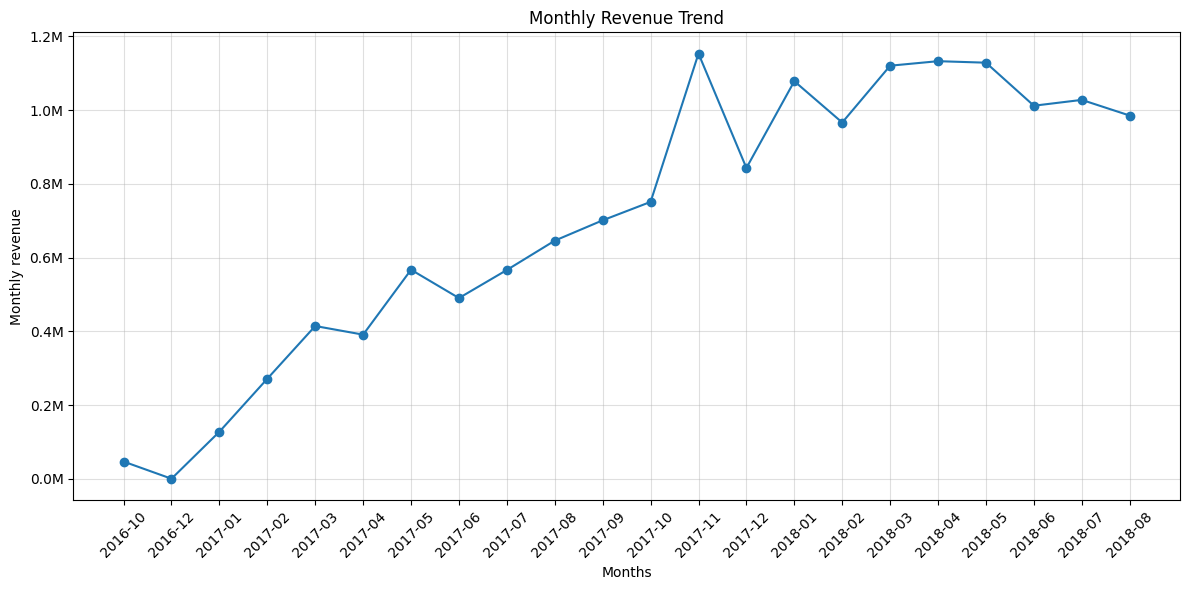

In [19]:
import matplotlib.ticker as ticker
query = '''SELECT substring(order_purchase_timestamp, 1,7) as months, SUM(OP.payment_value) as Monthly_rev
FROM ORDERS O
JOIN order_payment OP
ON O.ORDER_ID = OP.ORDER_ID
WHERE O.ORDER_STATUS = 'delivered'
GROUP BY substring(order_purchase_timestamp, 1,7) 
ORDER BY months;'''
df = pd.read_sql(query,engine)
df['Perc_change'] = round(df['Monthly_rev'].pct_change()*100, 2)
df['Rolling_rev'] = df['Monthly_rev'].cumsum()
df.set_index('months', inplace = True)

print(df['Monthly_rev'].max())
print(df['Monthly_rev'].min())
df.fillna(0, inplace = True)

print(df)


plt.figure(figsize=(12,6))
plt.plot(df.index, df['Monthly_rev'], marker = 'o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Months')
plt.ylabel('Monthly revenue')
plt.xticks(rotation = 45)

ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)
plt.tight_layout()
plt.grid(alpha = 0.4)
plt.show()
df.to_csv("Monthly_revenue.csv", index = True)

The maximum revenue is reported in November month of year 2017 which comes to be 1153528.05.
The minimum revenue is reported in December month of year 2016 which comes to be 19.62.
The Maximum Growth in monthly revenue is seen in the month of January 2017 where the revenue grows by 649979%.
The Least Growth is seen in the month of December 2016 where the revenue decreases by 99.96%.

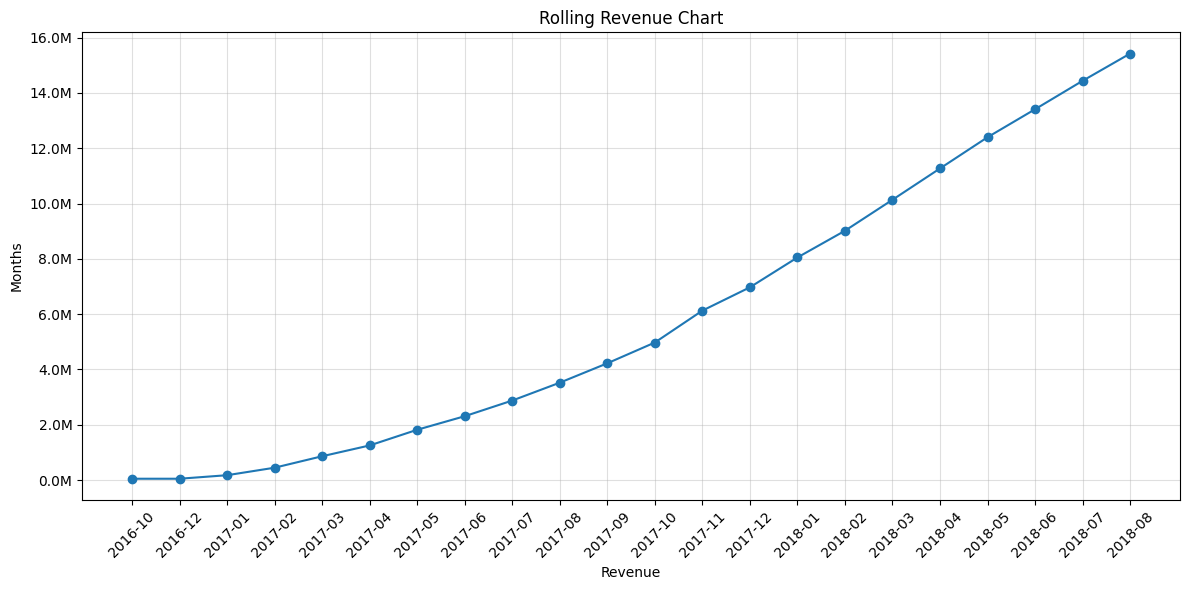

In [20]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Rolling_rev'], marker = 'o')
plt.title('Rolling Revenue Chart')
plt.xlabel('Revenue')
plt.ylabel('Months')
plt.xticks(rotation = 45)

ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

plt.tight_layout()
plt.grid(alpha = 0.4)
plt.show()

<Figure size 1500x1000 with 0 Axes>

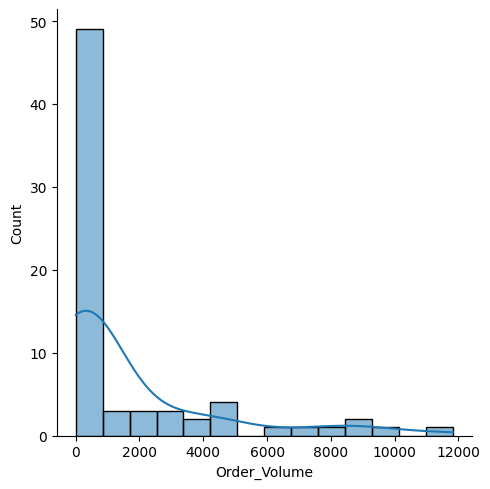

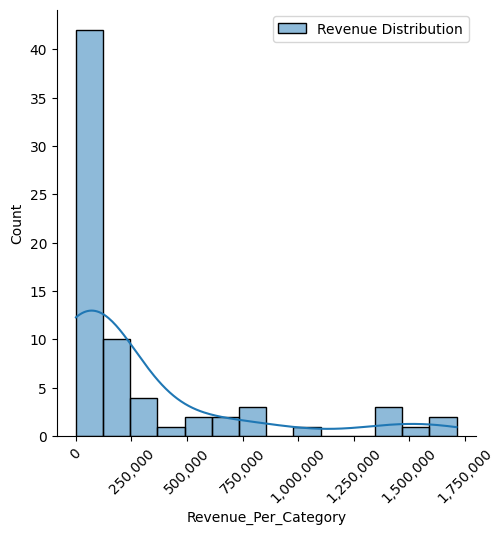

In [21]:
query='''SELECT C.product_category_name_english AS CATEGORY,
SUM(OP.payment_value) AS Revenue_Per_Category,
count(OI.order_id) as Order_Volume, 
SUM(OP.payment_value)/count(OI.order_id) AS AVG_ORDER_VAL
FROM CATEGORY C 
JOIN PRODUCTS P 
ON C.product_category_name = P.product_category
JOIN order_items OI
ON P.product_id = OI.product_id
JOIN order_payment OP
ON OI.order_id = OP.order_id
GROUP BY C.product_category_name_english
ORDER BY Revenue_Per_Category DESC;'''
df = pd.read_sql(query, engine)
# print(df)
plt.figure(figsize = (15,10))
sns.displot(df['Order_Volume'], kde =True, label = 'Order Distribution' )
sns.displot(df['Revenue_Per_Category'], kde = True , label = 'Revenue Distribution' )
ax = plt.gca()

ax.xaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}')
)
plt.xticks(rotation = 45)
plt.legend()
plt.show()


## Phase 4 - Customer Analysis


In [22]:
query = '''SELECT C.CUSTOMER_UNIQUE_ID AS CUS_ID, SUM(OP.payment_value) REV_PER_CUS
FROM ORDERS O 
JOIN CUSTOMERS C
ON O.CUSTOMER_ID = C.CUSTOMER_ID
JOIN order_payment OP
ON O.ORDER_ID = OP.ORDER_ID 
WHERE O.ORDER_STATUS = 'delivered'
GROUP BY C.CUSTOMER_UNIQUE_ID
ORDER BY REV_PER_CUS DESC;'''
df = pd.read_sql(query,engine)
print(df.head())
print(df.info())
print(df['REV_PER_CUS'].max())
print(df['REV_PER_CUS'].min())
high_spenders = (df['REV_PER_CUS']>=1000.0)
avg_spenders = (df['REV_PER_CUS']>150.0) & (df['REV_PER_CUS']<1000.0)
low_spenders = (df['REV_PER_CUS']<150.0)
print(round(df.loc[high_spenders, ['REV_PER_CUS']].mean(), 2))
print(round(df.loc[avg_spenders, ['REV_PER_CUS']].mean(), 2))
print(round(df.loc[low_spenders, ['REV_PER_CUS']].mean(), 2))
high_contri = round(df.loc[high_spenders, ['REV_PER_CUS']].sum()/df['REV_PER_CUS'].sum()*100, 2)
avg_contri = round(df.loc[avg_spenders, ['REV_PER_CUS']].sum()/df['REV_PER_CUS'].sum()*100, 2)
low_contri = round(df.loc[low_spenders, ['REV_PER_CUS']].sum()/df['REV_PER_CUS'].sum()*100, 2)
print(high_contri)
print(avg_contri)
print(low_contri)
df.to_csv("customer_revenue.csv", index = False)

                             CUS_ID  REV_PER_CUS
0  0a0a92112bd4c708ca5fde585afaa872     13664.08
1  da122df9eeddfedc1dc1f5349a1a690c      7571.63
2  763c8b1c9c68a0229c42c9fc6f662b93      7274.88
3  dc4802a71eae9be1dd28f5d788ceb526      6929.31
4  459bef486812aa25204be022145caa62      6922.21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93357 entries, 0 to 93356
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CUS_ID       93357 non-null  object 
 1   REV_PER_CUS  93357 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.4+ MB
None
13664.08
9.59
REV_PER_CUS    1584.3
dtype: float64
REV_PER_CUS    286.23
dtype: float64
REV_PER_CUS    79.29
dtype: float64
REV_PER_CUS    11.8
dtype: float64
REV_PER_CUS    56.42
dtype: float64
REV_PER_CUS    31.77
dtype: float64


There are a total of 93357 distinct customers.
The maximum expenditure by a single customer is 13664.08 while the minimum expenditure is 9.59.
A total of 1149 customers spend over 1000.0 and hence fall under the high spenders bracket.
A total of 30398 customers spend between 150.0 and 1000.0 and hence fall under the avg spenders bracket.
The remaining 61804 customers who spend below 150.0 fall under low spenders bracket.
The overall average expenditure of a customer is 165.2.
The average expenditure of a high spending customer is 1584.3, while that of a average spending and low spending customer is 286.23 and 79.29 respectively.
High spenders contribute about 11.8% to overall revenue.
Avg spenders contribute about 56.42% to overall revenue.
Low spenders contribute about 31.77% to overall revenue.


[]

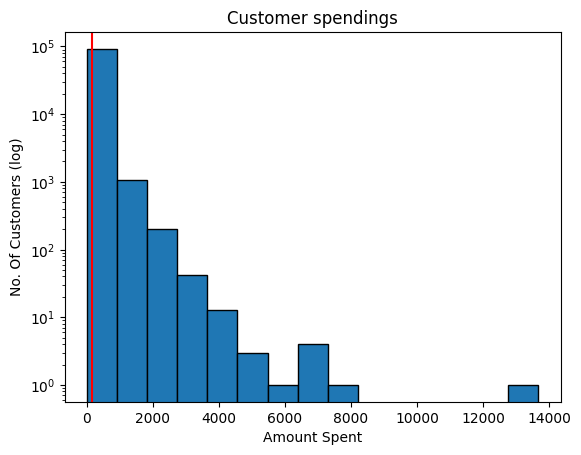

In [23]:
spendings = df['REV_PER_CUS']
median_spending = df['REV_PER_CUS'].mean()
plt.hist(spendings, bins = 15, edgecolor = 'black', log = True)
plt.axvline(median_spending, color = 'red')
plt.title('Customer spendings')
plt.xlabel('Amount Spent')
plt.ylabel('No. Of Customers (log)')
plt.plot()

1820362
8700942


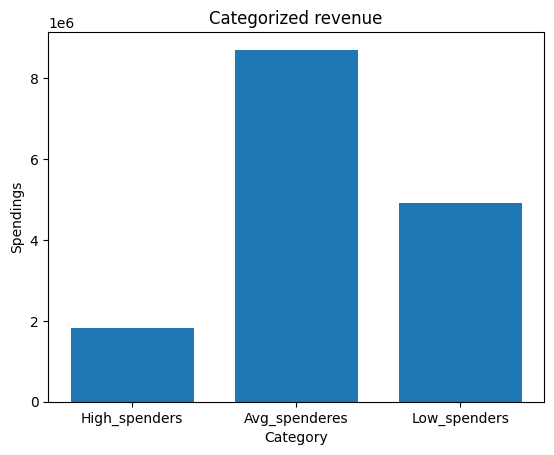

In [24]:
high_spending = df.loc[high_spenders, ['REV_PER_CUS']].sum()
avg_spending = df.loc[avg_spenders, ['REV_PER_CUS']].sum()
low_spending = df.loc[low_spenders, ['REV_PER_CUS']].sum()
print(round(high_spending.iloc[0]))
print(round(avg_spending.iloc[0]))
spendings = [round(high_spending.iloc[0]), round(avg_spending.iloc[0]), round(low_spending.iloc[0])]
label = ['High_spenders', 'Avg_spenderes', 'Low_spenders']
plt.bar(label, spendings, width = 0.75)
plt.title('Categorized revenue')
plt.xlabel('Category')
plt.ylabel('Spendings')
plt.show()

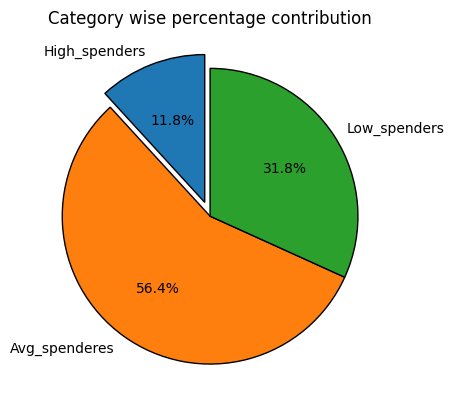

In [25]:
slices = [round(high_spending.iloc[0]), round(avg_spending.iloc[0]), round(low_spending.iloc[0])]
label = ['High_spenders', 'Avg_spenderes', 'Low_spenders']
explode = [0.1,0,0]
plt.pie(slices, labels = label,explode = explode, startangle = 90, autopct = '%1.1f%%', wedgeprops={'edgecolor':'black'} )
plt.title('Category wise percentage contribution')
plt.show()

       REV_PER_CUS segment
0         13664.08    High
1          7571.63    High
2          7274.88    High
3          6929.31    High
4          6922.21    High
...            ...     ...
93352        11.63     Low
93353        11.63     Low
93354        10.89     Low
93355        10.07     Low
93356         9.59     Low

[93351 rows x 2 columns]


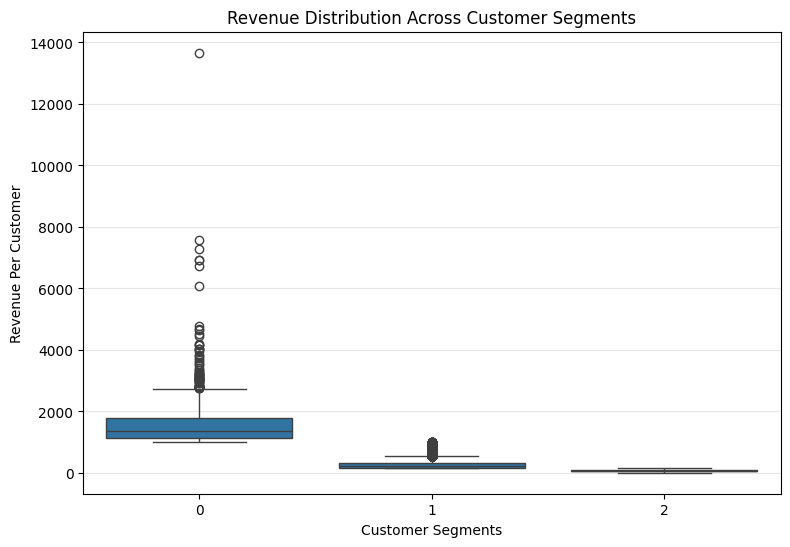

In [26]:
high_spender_cus = df.loc[high_spenders, ['REV_PER_CUS']]
avg_spender_cus = df.loc[avg_spenders, ['REV_PER_CUS']]
low_spender_cus = df.loc[low_spenders, ['REV_PER_CUS']]

high_spender_cus['segment'] = 'High'
avg_spender_cus['segment'] = 'Avg'
low_spender_cus['segment'] = 'Low'

box_df = pd.concat([
    high_spender_cus,
    avg_spender_cus,
    low_spender_cus
])
print(box_df)
plt.figure(figsize = (9,6))

sns.boxplot(x='segment', y='REV_PER_CUS', data = box_df)
ax = plt.gca()

ax.xaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}')
)
plt.xlabel('Customer Segments')
plt.ylabel('Revenue Per Customer')
plt.title('Revenue Distribution Across Customer Segments')

plt.grid(axis='y', alpha = 0.3)
plt.show()

## PHASE 5 - RFM ANALYSIS

In [27]:
query = '''SELECT C.customer_unique_id AS CUST_UNQ_ID,
count(DISTINCT O.order_id) as FREQUENCY,
MAX(order_purchase_timestamp) as LAST_PURCHASE,
SUM(OP.payment_value) AS MONETARY
FROM orders O 
JOIN customers C 
ON O.customer_id = C.customer_id
JOIN order_payment OP
ON O.order_id = OP.order_id
WHERE O.order_status = 'delivered'
GROUP BY C.customer_unique_id ;
''' 
df = pd.read_sql(query, engine)
df['LAST_PURCHASE'] = pd.to_datetime(df['LAST_PURCHASE'])
reference_date = df['LAST_PURCHASE'].max() + pd.Timedelta(days=1)
df['RECENCY'] = reference_date - df['LAST_PURCHASE']
# df['RECENCY'] = pd.to_timedelta(df['RECENCY'])
conditions = [
    df['FREQUENCY'] >= 5,
    df['FREQUENCY'] == 4,
    df['FREQUENCY'] == 3,
    df['FREQUENCY'] == 2,
    df['FREQUENCY'] == 1,
]
choice = [5,4,3,2,1]
df['FREQUENCY SCORE'] = np.select(
    conditions,
    choice
)

conditions = [
    df['MONETARY'] >= 3000,
    (df['MONETARY'] >= 2000) & (df['MONETARY'] <= 3000),
    (df['MONETARY'] >= 1000) & (df['MONETARY'] <= 2000),
    (df['MONETARY'] >= 500) & (df['MONETARY'] <= 1000),
    df['MONETARY'] <= 500,
]
choice = [5,4,3,2,1]
df['MONETARY SCORE'] = np.select(
    conditions,
    choice
)
df['RECENCY'] = df['RECENCY'].dt.days

conditions = [
    df['RECENCY'] <= 30,
    (df['RECENCY'] <= 100) & (df['RECENCY'] >30), 
    (df['RECENCY'] <= 300) & (df['RECENCY'] >100), 
    (df['RECENCY'] <= 500) & (df['RECENCY'] >300),
    df['RECENCY'] > 500
]
choice = [5,4,3,2,1]
df['RECENCY SCORE'] = np.select(
    conditions,
    choice
)
df.head()

filt_best = (df['FREQUENCY SCORE'] >= 4) & (df['MONETARY SCORE'] >= 4) & (df['RECENCY SCORE'] >= 4)
best_customers = df[filt_best]

filt_loyal = (df['FREQUENCY SCORE'] >= 4) 
loyal_customers = df[filt_loyal]

filt_big = (df['MONETARY SCORE'] >= 4)
big_spenders = df[filt_big]

filt_new = (df['FREQUENCY SCORE'] == 1) & (df['RECENCY SCORE'] >= 4)
new_customers = df[filt_new]

filt_lost = (df['RECENCY SCORE'] <= 2)
lost_customers = df[filt_lost]

filt_big_new = (df['FREQUENCY SCORE'] == 1) & (df['RECENCY SCORE'] >= 4) & (df['MONETARY SCORE'] >= 4)
big_new_customers = df[filt_big_new]

filt_repeat = df['FREQUENCY SCORE'] > 1 
repeat_customers  = df[filt_repeat]
# print(df['RECENCY'].max())
# sns.boxplot(y = 'RECENCY', data = df)
# plt.grid(axis = 'y', alpha = 0.3)
# plt.show()

print(best_customers)

# loyal_cus_rev = round(loyal_customers['MONETARY'].sum())
# total_rev = round(df['MONETARY'].sum())
# loyal_cus_perc = loyal_cus_rev/total_rev*100
# print(round(loyal_cus_perc,2))
# print(round(loyal_customers['MONETARY'].mean(),2))
# print(round(loyal_customers['FREQUENCY'].mean(),2))

# print(big_spenders.info())
# big_cus_rev = round(big_spenders['MONETARY'].sum())
# total_rev = round(df['MONETARY'].sum())
# big_cus_perc = big_cus_rev/total_rev*100
# print(big_cus_rev)
# print(round(big_cus_perc,2))
# print(round(big_spenders['MONETARY'].mean(),2))
# print(round(big_spenders['FREQUENCY'].mean(),2))


# print(new_customers.info())
# new_cus_rev = round(new_customers['MONETARY'].sum())
# total_rev = round(df['MONETARY'].sum())
# new_cus_perc = new_cus_rev/total_rev*100
# print(new_cus_rev)
# print(round(new_cus_perc,2))
# print(round(new_customers['MONETARY'].mean(),2))
# print(round(new_customers['FREQUENCY'].mean(),2))
# print(new_customers['CUST_UNQ_ID'].count())


# print(lost_customers.info())
# lost_cus_rev = round(lost_customers['MONETARY'].sum())
# total_rev = round(df['MONETARY'].sum())
# lost_cus_perc = lost_cus_rev/total_rev*100
# print(lost_cus_rev)
# print(round(lost_cus_perc,2))
# print(round(lost_customers['MONETARY'].mean(),2))
# print(round(lost_customers['FREQUENCY'].mean(),2))
# print(lost_customers['CUST_UNQ_ID'].count())


# print(big_new_customers.info())
# big_new_cus_rev = round(big_new_customers['MONETARY'].sum())
# total_rev = round(df['MONETARY'].sum())
# big_new_cus_perc = big_new_cus_rev/total_rev*100
# print(big_new_cus_rev)
# print(round(big_new_cus_perc,2))
# print(round(big_new_customers['MONETARY'].mean(),2))
# print(round(big_new_customers['FREQUENCY'].mean(),2))
# print(big_new_customers['CUST_UNQ_ID'].count())


# print(df.info())
# print(repeat_customers.info())
# repeat_cus_rev = round(repeat_customers['MONETARY'].sum())
# total_rev = round(df['MONETARY'].sum())
# repeat_cus_perc = repeat_cus_rev/total_rev*100
# print(repeat_cus_rev)
# print(round(repeat_cus_perc,2))
# print(round(repeat_customers['MONETARY'].mean(),2))
# print(round(repeat_customers['FREQUENCY'].mean(),2))
# print(repeat_customers['CUST_UNQ_ID'].count())

df.head(10)
df.to_csv("rfm_analysis.csv", index = False)


                            CUST_UNQ_ID  FREQUENCY       LAST_PURCHASE  \
73126  c8460e4251689ba205045f3ea17884a1          4 2018-08-08 14:27:15   

       MONETARY  RECENCY  FREQUENCY SCORE  MONETARY SCORE  RECENCY SCORE  
73126   4655.91       22                4               5              5  


Text(-3.6805555555555554, 0.5, 'No. of Customers')

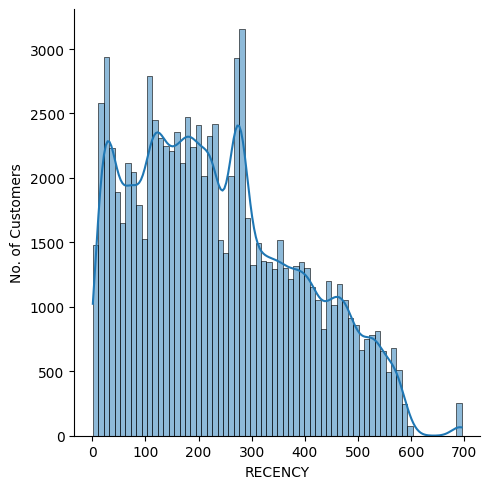

In [28]:
sns.displot(df['RECENCY'], kde = True, kind="hist")
plt.ylabel('No. of Customers')

Text(-12.430555555555555, 0.5, 'No. of Customers')

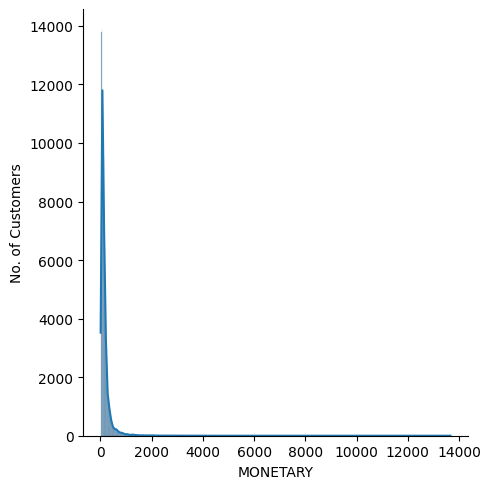

In [29]:
sns.displot(df['MONETARY'], kde= True, kind='hist')
plt.ylabel('No. of Customers')

Text(-12.430555555555555, 0.5, 'No. of Customers')

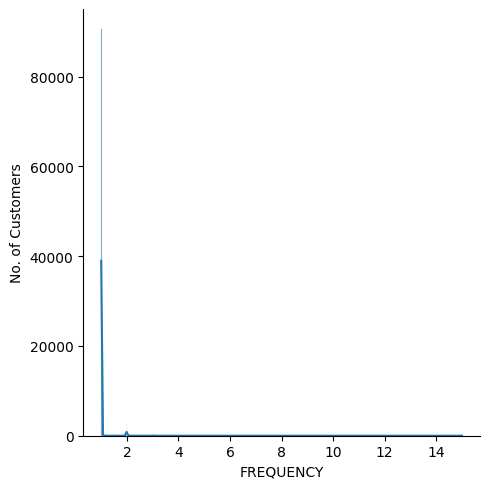

In [30]:
sns.displot(df['FREQUENCY'], kde=True)
plt.ylabel('No. of Customers')

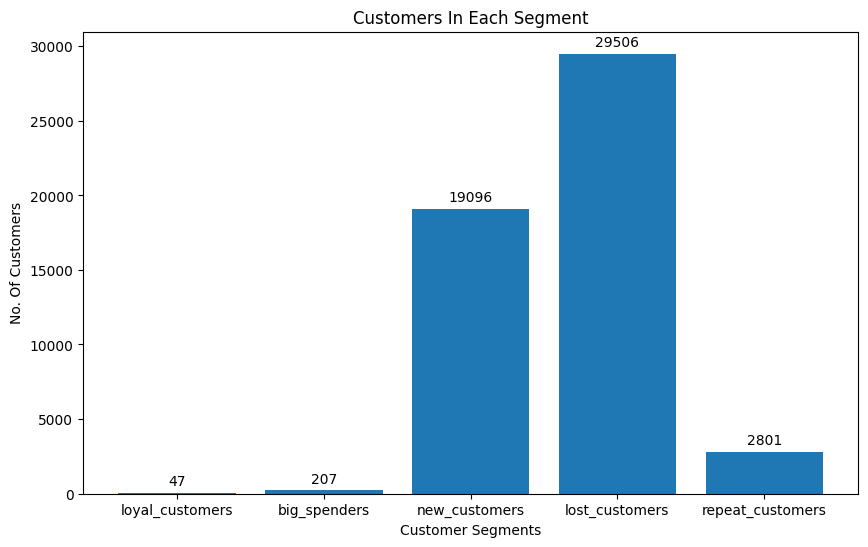

In [31]:
cust_nos = [loyal_customers['CUST_UNQ_ID'].count(), big_spenders['CUST_UNQ_ID'].count(), new_customers['CUST_UNQ_ID'].count(), lost_customers['CUST_UNQ_ID'].count(), 
           repeat_customers['CUST_UNQ_ID'].count()]
label = ['loyal_customers', 'big_spenders', 'new_customers', 'lost_customers', 
           'repeat_customers']

fig, ax = plt.subplots(figsize = (10,6))
bars = ax.bar(label, cust_nos)
plt.xlabel('Customer Segments')
plt.ylabel('No. Of Customers')
plt.title('Customers In Each Segment')
ax.bar_label(bars, padding = 3)
plt.show()

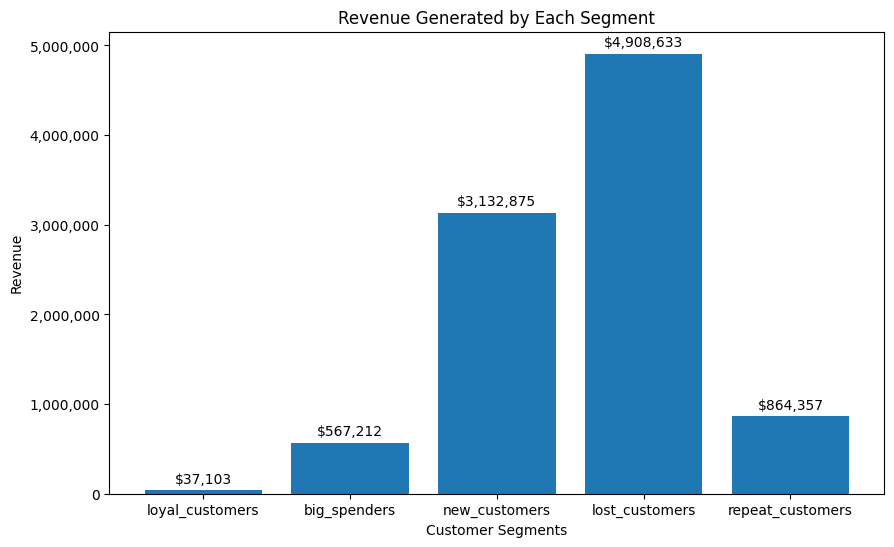

In [32]:
from matplotlib.ticker import StrMethodFormatter

segment_rev = cust_nos = [loyal_customers['MONETARY'].sum(), big_spenders['MONETARY'].sum(), new_customers['MONETARY'].sum(), lost_customers['MONETARY'].sum(), 
           repeat_customers['MONETARY'].sum()]
fig, ax = plt.subplots(figsize = (10,6))
bars = ax.bar(label, segment_rev)
plt.xlabel('Customer Segments')
plt.ylabel('Revenue')
plt.title('Revenue Generated by Each Segment')
ax.bar_label(bars,
             labels=[f"${v:,.0f}" for v in segment_rev],
             padding = 3)
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.show()


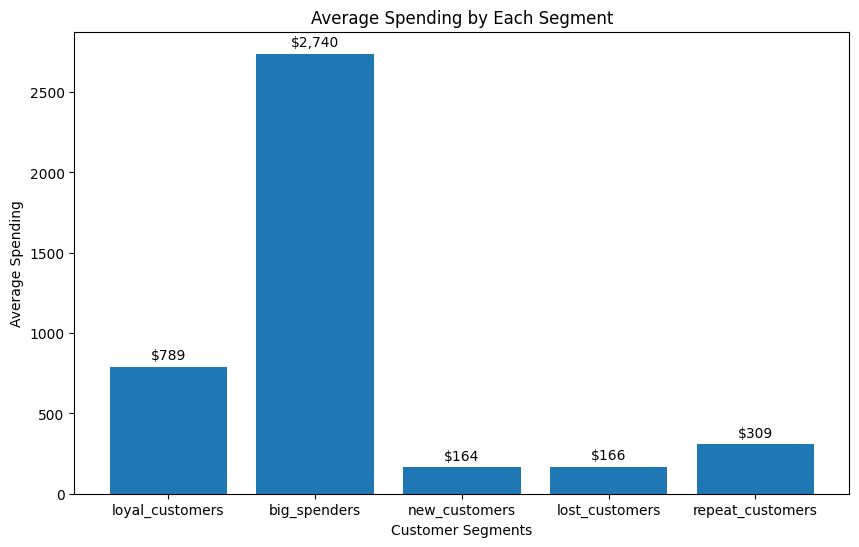

In [33]:
segment_avg = cust_nos = [loyal_customers['MONETARY'].mean(), big_spenders['MONETARY'].mean(), new_customers['MONETARY'].mean(), lost_customers['MONETARY'].mean(), 
           repeat_customers['MONETARY'].mean()]
fig, ax = plt.subplots(figsize = (10,6))
bars = ax.bar(label, segment_avg)
plt.xlabel('Customer Segments')
plt.ylabel('Average Spending')
plt.title('Average Spending by Each Segment')
ax.bar_label(bars,
             labels=[f"${v:,.0f}" for v in segment_avg],
             padding = 3)
plt.show()

1. There is only one customer that falls under the best customer category with customer_unique_id 'c8460e4251689ba205045f3ea17884a1' with the score of 4, 5, 4 in Frequency, Monetary, Recency respectively.
2. There are a total of 47 customers that fall under loyal customers category i.e. those who have made a purchase 4 or more times. Their contribution to revenue comes out to be 37103 which makes up 0.24 % of the total revenue. The average order value is 789.42 and the average frequency is 4.94.
3. There are a total of 207 customers that fall under big spending customers category i.e. the customers spending over 2000 . Their contribution to revenue comes out to be 567212 which makes up 3.68 % of the total revenue. The average order value is 2740.16 and the average frequency is 1.07.
4. There are a total of 19904 customers that fall under new customers category i.e. those who have only purchased only once and in less than 100 days. Their contribution to revenue comes out to be 3120483 which makes up 20.23 % of the total revenue. The average order value is 164.2 and the average frequency is 1.
5. There are a total of 29574 customers that fall under lost customers category i.e. those who made their last purchase 300 or more days ago. Their contribution to revenue comes out to be 4919858 which makes up 31.9 % of the total revenue. The average order value is 166.36 and the average frequency is 1.03.
6. There comes an intresting category of new big spending customers consisting a total of 54 customers with revenue contribution of 151492 and making 0.98 % of total revenue. The average order value is 2805.41. 
7. There are a total of 2801 repeat customers which makes up 3 % of total customers. Their contribution to the revenue is 864357 which makes up 5.6 % of total revenue. Their average order value is 308.59 and the average frequency is 2.11.

## Business Insights based on RFM Analysis
1. The repeat customers are very few and makes up only 3 % of total customers but their contribution to revenue is 5.6 % which means their are highly benificial for the business so we must make sure to keep them with us by providing some extra perks to them and also try to increase the number of repeat customers because there is a lot of scope there.
2. There are 19904 new customers which make up 21.3 % of total customers and their revenue contribution is 20.23 % so we must work to make them our loyal customers.
3. There are only 207 big spending customers which is a mere 0.22 % of total customers but their contribution to reveenuee is 3.68 % which is significant so we must make sure they stay with us and we should give them exclusive offers so that more play enter this club.
4. There are a total of 47 loyal customers which make up 0.05 % 0f total customers and this clearly shows that there is a huge scope of improvement in this area as their revenue contribution is quite significant at 0.24 % compares to their number which is also evident from the avg order value.
5. The area of lost customers is the one with the most scope and need of improvement with a total of 29574 customers making up 31.67 % of total customers and 31.9 % of total revenue which is a really significant number so we must work to attract these customers back and get them to do business with us once again. 

## PHASE 6 - DELIVERY ANALYSIS

In [62]:
query = '''SELECT order_id, 
DATEDIFF(order_delivered_customer_date, order_approved_at) AS delivery_days,
TIMESTAMPDIFF(HOUR, order_approved_at, order_delivered_customer_date) as delivery_hours,
DATEDIFF(order_estimated_delivery_date, order_approved_at) AS estimated_delivery_days,
TIMESTAMPDIFF(HOUR, order_approved_at, order_estimated_delivery_date) as estimated_delivery_hours,
TIMESTAMPDIFF(HOUR, order_purchase_timestamp, order_approved_at) as approval_time,
TIMESTAMPDIFF(HOUR, order_approved_at, order_delivered_carrier_date) as seller_processing_hours,
C.customer_city as customer_city, C.customer_state as customer_state
FROM ORDERS O
JOIN CUSTOMERS C 
ON O.customer_id = C.customer_id
WHERE order_status = 'delivered';'''

query2 = '''SELECT
    OP.order_id as order_id,
    C.product_category_name_english as product_category
FROM order_items OP
JOIN products P
    ON OP.product_id = P.product_id
JOIN category C
    ON P.product_category = C.product_category_name;'''

df = pd.read_sql(query, engine)
category_df = pd.read_sql(query2 , engine)


df['estimate_actual_days'] = df['estimated_delivery_days'] - df['delivery_days']
df['estimate_actual_hours'] = df['estimated_delivery_hours'] - df['delivery_hours']

filt = (df['delivery_days'] < 0) | (df['delivery_hours'] < 0) | (df['seller_processing_hours'] > df['delivery_hours']) | (df["seller_processing_hours"] < 0 ) # "Orders delivered in under 12 hours were retained because they are operationally possible."
invalid_rows = df[filt]
# print(invalid_rows.info())
df = df[~filt]

category_df = pd.merge(df, category_df, on = 'order_id', how = 'left')
# print(category_df.info())

filt1 = category_df['delivery_days'] > 50
overly_delayed = category_df[filt1]

conditions = [
    df['estimate_actual_days'] > 0,
    df['estimate_actual_days'] == 0,
    df['estimate_actual_days'] < 0,
]
choice = ['Before estimate', 'On time', 'After estimate']
df['delivery_status'] = np.select(
    conditions,
    choice,
    default='Not Classified'
)

before_estimate = df['delivery_status'].value_counts().loc['Before estimate']
after_estimate = df['delivery_status'].value_counts().loc['After estimate']
on_time = df['delivery_status'].value_counts().loc['On time']
total_orders = df['order_id'].count()

before_estimate_pct = before_estimate/total_orders*100
after_estimate_pct = after_estimate/total_orders*100
on_time_pct = on_time/total_orders*100

# print(df.head(10));

print("Average delivery Days : ", round(df['delivery_days'].mean(),2))
print("Average delivery Hours : ",round(df['delivery_hours'].mean(),2))
print("Average approval time : ",round(df['approval_time'].mean(),2))
print("Average Seller Processing Hours : ",round(df['seller_processing_hours'].mean(),2))
print("Median Delivery Days : ",df['delivery_days'].median())
print("Median Delivery Hours : ",df['delivery_hours'].median())
print("Median approval time : ",df['approval_time'].median())
print("Median Seller Processing hours : ",df['seller_processing_hours'].median())
print('Longest Delivery Days : ',df['delivery_days'].max())
print('Longest Delivery Hours : ',df['delivery_hours'].max())
print('Quickest Delivery Hours : ',df['delivery_hours'].min())
print('Longest approval time : ',df['approval_time'].max())
print('Longest Seller Processing hours : ',df['seller_processing_hours'].max())
print('Standard Deviation (Delivery Days): ',round(df['delivery_days'].std(),2))
print('Standard Deviation (Delivery Hours): ',round(df['delivery_hours'].std(),2))
print('Standard Deviation (Approval Time): ',round(df['approval_time'].std(),2))
print('Standard Deviation (Seller Processing Hours): ',round(df['seller_processing_hours'].std(),2))
print("90th percentile : ", df['delivery_days'].quantile(0.90), 'days')
print("90th percentile (Approval Time): ", df['approval_time'].quantile(0.90), 'hours')
print("90th percentile (Seller Processing Hours): ", df['seller_processing_hours'].quantile(0.90), 'hours')
print("95th percentile : ", df['delivery_days'].quantile(0.95), 'days')
p75 = df['delivery_days'].quantile(0.75)
p25 = df['delivery_days'].quantile(0.25)
icr = p75 - p25
print("Inter Quartile Range : ",icr,'days')
print(round(before_estimate_pct,2))
print(round(after_estimate_pct,2))
print(round(on_time_pct,2))
# df.sort_values(by = 'seller_processing_hours', ascending = False, inplace = True)
# df[df['seller_processing_hours']> df['delivery_hours']]
# df.head(30)


# state_grp = df.groupby('customer_state')
# state_stats = state_grp.agg(
#     avg_delivery_days = ('delivery_days', 'mean'),
#     avg_delivery_hours = ('delivery_hours', 'mean'),
#     std_days = ('delivery_days', 'std'),
#     actual_estimate_diff = ('estimate_actual_days', 'mean'),
#     no_of_orders = ('order_id', 'count')
# )
# state_stats.sort_values(by=['avg_delivery_days', 'avg_delivery_hours'], ascending = False, inplace = True)
# print(state_stats['actual_estimate_diff'].idxmax())
# print(state_stats['actual_estimate_diff'].idxmin())
# print(state_grp['delivery_days'].quantile(0.90))
# state_stats

# city_grp = df.groupby('customer_city')
# city_stats = city_grp.agg(
#     avg_delivery_days = ('delivery_days', 'mean'),
#     avg_delivery_hours = ('delivery_hours', 'mean'),
#     std_days = ('delivery_days', 'std'),
#     actual_estimate_diff = ('estimate_actual_days', 'mean'),
#     no_of_orders = ('order_id', 'count')
# )
# city_stats.sort_values(by=['actual_estimate_diff'], ascending = True, inplace = True)
# city_stats = city_stats[city_stats['no_of_orders']>20]                 #Cities with fewer than 20 deliveries were excluded to reduce statistical noise.
# city_stats.head(10)

category_grp = category_df.groupby('product_category')
category_stats = category_grp.agg(
    avg_delivery_days = ('delivery_days', 'mean'),
    avg_delivery_hours = ('delivery_hours', 'mean'),
    actual_estimate_diff = ('estimate_actual_days', 'mean'),
    std_days = ('delivery_days', 'std'),
    no_of_orders = ('order_id', 'count')
)
category_stats.sort_values(by=['avg_delivery_days', 'avg_delivery_hours'], ascending = False, inplace = True)
category_stats

# category_stats.to_csv("category_wise_delivery.csv", index=True)
df


Average delivery Days :  12.06
Average delivery Hours :  292.39
Average approval time :  9.3
Average Seller Processing Hours :  67.77
Median Delivery Days :  10.0
Median Delivery Hours :  238.0
Median approval time :  0.0
Median Seller Processing hours :  44.0
Longest Delivery Days :  208.0
Longest Delivery Hours :  5004.0
Quickest Delivery Hours :  12.0
Longest approval time :  741.0
Longest Seller Processing hours :  3018.0
Standard Deviation (Delivery Days):  9.53
Standard Deviation (Delivery Hours):  228.58
Standard Deviation (Approval Time):  19.05
Standard Deviation (Seller Processing Hours):  83.55
90th percentile :  23.0 days
90th percentile (Approval Time):  33.0 hours
90th percentile (Seller Processing Hours):  144.0 hours
95th percentile :  29.0 days
Inter Quartile Range :  9.0 days
91.8
6.83
1.35


,order_id,delivery_days,delivery_hours,estimated_delivery_days,estimated_delivery_hours,approval_time,seller_processing_hours,customer_city,customer_state,estimate_actual_days,estimate_actual_hours,delivery_status
0,f11b36b3bc7bacf06deef862ed611f02,6.0,161.0,14.0,332.0,18.0,12.0,guaruja,SP,8.0,171.0,Before estimate
1,0daf1f0e67b534ad873ba61c5d6ad7d3,13.0,316.0,19.0,444.0,24.0,74.0,rio de janeiro,RJ,6.0,128.0,Before estimate
2,4a5cc9b4e332e03d76bf553a7f2fa5d3,16.0,406.0,29.0,695.0,48.0,25.0,belford roxo,RJ,13.0,289.0,Before estimate
3,47770eb9100c2d0c44946d9cf07ec65d,9.0,225.0,27.0,639.0,0.0,4.0,vianopolis,GO,18.0,414.0,Before estimate
4,5f69f6bf68dce110479aa0bb515b47c8,4.0,97.0,16.0,372.0,0.0,29.0,ribeirao pires,SP,12.0,275.0,Before estimate
...,...,...,...,...,...,...,...,...,...,...,...,...
96473,810c6a01f9a077313109b64e36165ecb,2.0,50.0,9.0,195.0,32.0,25.0,sao paulo,SP,7.0,145.0,Before estimate
96474,744b5f76be2964239912826181a4cf54,1.0,25.0,10.0,226.0,21.0,21.0,sao bernardo do campo,SP,9.0,201.0,Before estimate
96475,f2afcdfbf3e9be7b7561ccd2a7e4a9cc,3.0,68.0,23.0,529.0,0.0,19.0,rio de janeiro,RJ,20.0,461.0,Before estimate
96476,4e743d407939e965ac0b7bb694e67eed,19.0,441.0,47.0,1112.0,0.0,238.0,curitiba,PR,28.0,671.0,Before estimate


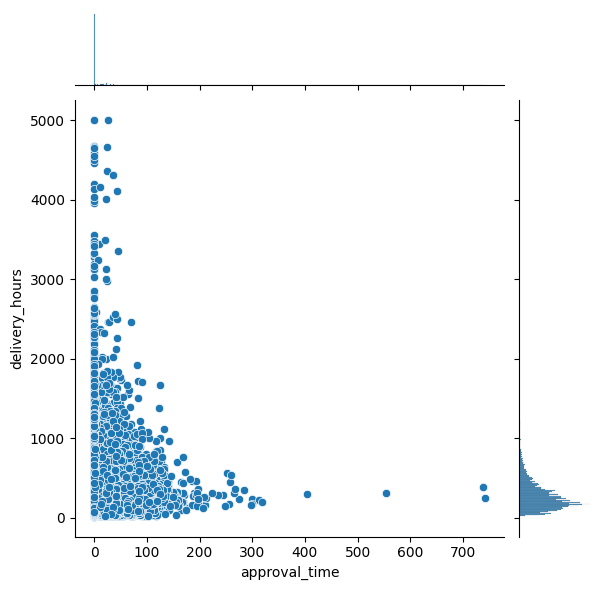

In [35]:
# correlational analysis
sns.jointplot(x = 'approval_time', y = 'delivery_hours', data = df, kind = 'scatter')



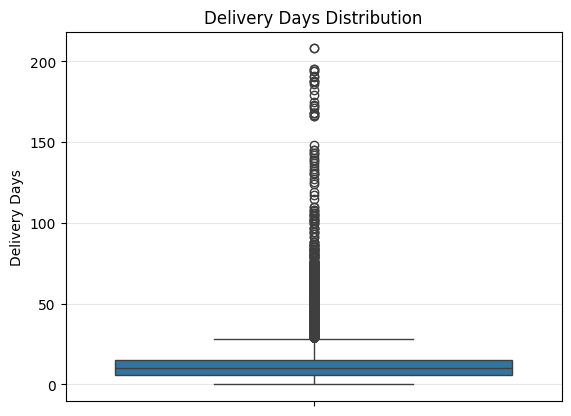

Text(0.5, 9.444444444444438, 'Delivery Days')

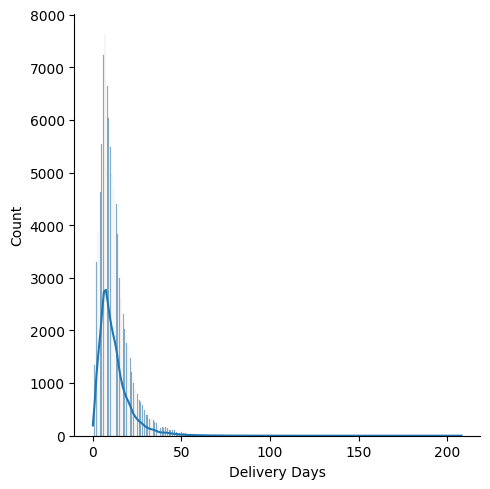

In [36]:
sns.boxplot(y = 'delivery_days', data = df)
plt.title('Delivery Days Distribution')
plt.ylabel('Delivery Days')
plt.grid(axis= 'y', alpha = 0.3)
plt.show()
sns.displot(df['delivery_days'], kde = True)
plt.xlabel('Delivery Days')


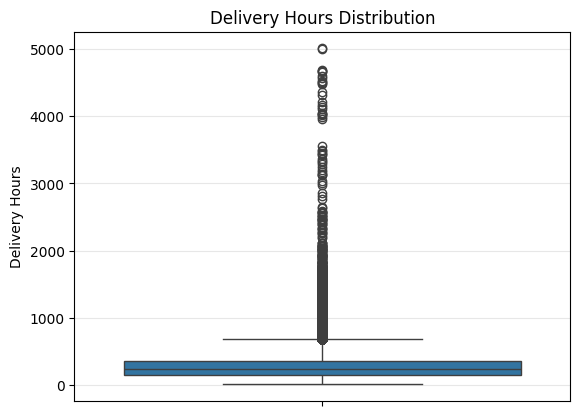

Text(0.5, 9.444444444444438, 'Delivery Hours')

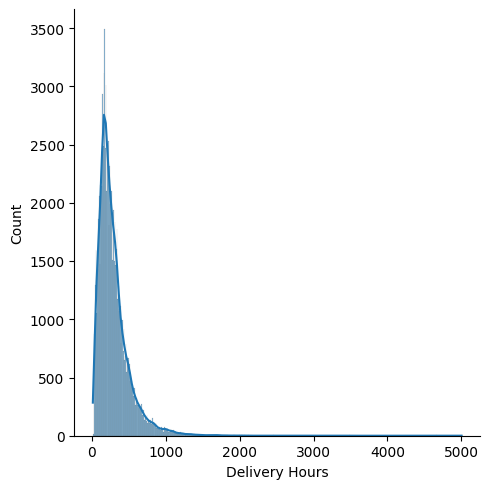

In [37]:
sns.boxplot(y = 'delivery_hours', data = df)
plt.title('Delivery Hours Distribution')
plt.ylabel('Delivery Hours')
plt.grid(axis= 'y', alpha = 0.3)
plt.show()
sns.displot(df['delivery_hours'], kde = True)
plt.xlabel('Delivery Hours')

##### There are a total of 76 rows/orders, around 0.076 % of total_orders, which are found to be invalid because they either have negative delivery_days or delivery_hours or their seller processing time is greater than the delivery time, and hence they have been removed before the analysis. 

1. The average days and hours taken to make a delivery are 11.99 and 290.83 repectively.
2. The median delivery days and delivery hours are 10 days and 236 hours respectively.
3. The longest delivery took 208 days in hours terms it comes out to be 5004 hours, while the quickest delivery was made in 1 hours.
4. The standard deviation for delivery days comes out to be 9.52 days while that for delivery hours is 228.33 hours.
5. The 90th percentile and 95th percentile for delivery days comes out to be 22 and 29 days respectively.
6. 91.86 % orders are delivered before estimate, 6.78 % are delivered after estimate and 1.34 % are delivered on the same day as estimated.
7. The average approval time is 24.96 hours, the median approval time comes out to be 19.0 hours while the longest it took to approve an order was found out to be 756 hours i.e. 31.5 days.
8. The standard deviation of approval time is 20.7 hours and the 90th percentile of approvale time comes out to be 51 hours indicating that 10 % of orders take more than 51 hours to get approved which is concerning and this time needs to be reduced.
9. The average time required to deliver an order to carrier is 66.74 hours, while the median comes out to be 43.0 hours and the longest delivery being 3018.0 hours.
10. The standard deviation of seller processing hours comes out to be 84.74 hours and the 90th percentile comes out to be 143 hours. 
14. The product category with the most average delivery days taken is office furniture with 20.01 days or 485.73 hours, followed by christmas supplies and fashion shoes with 15.21 and 15 average delivery days respectively.
15. The product category with the least average delivery days is art and craftmansghip with 4.75 days or 118.75 hours, followed by la cuisine and imported books with 7.42 and 7.45 average delivery days respectively.




 

1. The state that takes the maximum time for delivery is RR with average delivery days and hours 28.83 and 695.32 respectively, accounting for 41 orders followed by AP and AM with average delivery days 26.46 and 25.88 and total orders 67 and 145 respectively.
2. The state that takes the minimum time for delivery is SP with average delivery days and hours 8.24 and 200.62 respectively, accounting for 40454 orders followed by by PR and MG with average delivery days 11.4 and 11.45 and total orders 4920 and 11352 respectively.
3. The state with highest 90th percentile is RR with a staggering value of 52 days but with 41 total orders followed by AL and PA both with 39 days and 397 and 946 total orders respectively.
4. The state with lowest 90th percentile is SP with 15 days, which also accounts for the maximum of 40454 total orders, followed by PR and MG with 19 and 20 days and 4920 and 11352 total orders respectively.
5. The state of AC experiences the most delay in orders as the average of difference between estimated and actual delivery dates for this state comes out to be the highest at 20.72 days (total orders = 80), followed by RO and AP with 20.10 and 19.68 days with 243 and 67 total orders respectively.
6. The state with the least delays in orders is AL with this avg of difference between estimated and actual delivery dates at just only 8.7 days and 397 orders, followed by MA and ES with 9.54 and 10.49 days and 717 and 1995 orders respectively.
7. The city of novo brasil has the highest avg delivery days i.e. 148 but it only has one 1 order which suggest that it is one of the remote cities, so we made of threshold of atleast 20 orders and in that threshold the city of santarem has the most avg delivery days and hours i.e. 32.30 and 777.79 respectively, followed by boa vistra and altamira with 29.1 and 27.2 avg delivery days respectively.
8. The city of poa has the least avg delivery days and hours at 5.96 days and 147 hours respectively, followed by the city of aruja and taboao da serra with 5.97 and 6.31 avg delivery days respectively.
9. The top 10 cities in order according to most average delivery days are santarem, boa vista, altamira, macapa, manaus, maceio, maraba, sobral, armacao dos buzios, arapiraca.
10. The top 10 cities in order according to least average delivery days are poa, aruja, taboao da serra, juquitiba, santana de parnaiba, cotia, franco da rocha, vargem grande paulista, braganca paulista, carapicuiba.
11. The 10 cities in order with the least delay in orders i.e. the difference between estimate and actual delivery date are marau, barra do garcas, sao gabriel, macapa, rio branco, osorio, manaus, porto velho, santiago, alegrete.
12. The 10 cities in order with the most delay in orders are armacao dos buzios, vera cruz, santarem, nova friburgo, tres lagoas, juazeiro, sao goncalo, cabo frio, maceio, monte mor.



## PHASE 7 - CUSTOMER EXPERIENCE ANALYSIS


Text(37.722222222222214, 0.5, 'Delivery time (in hours)')

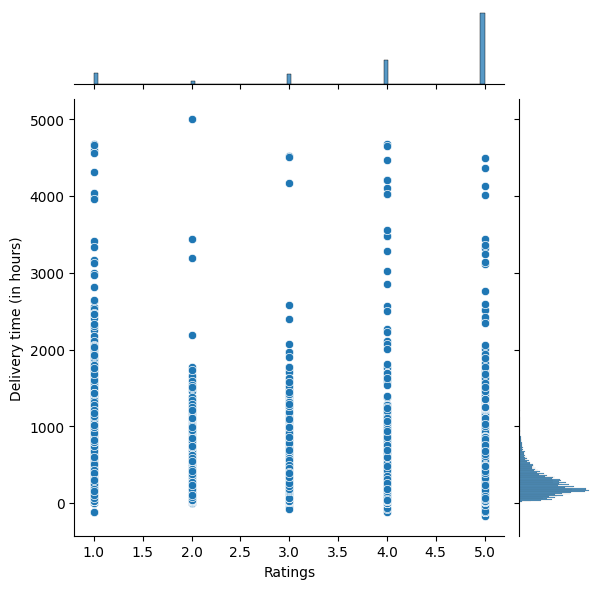

In [38]:
query = '''SELECT O.order_id as order_id, 
DATEDIFF(O.order_delivered_customer_date, O.order_approved_at) AS delivery_days,
TIMESTAMPDIFF(HOUR, O.order_approved_at, O.order_delivered_customer_date) as delivery_hours,
TIMESTAMPDIFF(HOUR, O.order_approved_at, O.order_estimated_delivery_date) as estimated_delivery_hours, 
OP.payment_value as Payment_value,
OP.payment_installments as Payment_installments,
R.review_score as Review_score
FROM orders O 
JOIN order_payment OP 
ON O.order_id = OP.order_id
JOIN review R 
ON O.order_id = R.order_id
WHERE O.order_status = 'delivered';'''

df = pd.read_sql(query, engine)

df['estimate_actual_diff'] = df['estimated_delivery_hours'] - df['delivery_hours']
df.drop_duplicates(inplace = True)
df.duplicated().sum()
# df.info()
# df[df.isna().any(axis=1)]

sns.jointplot(y='delivery_hours', x = 'Review_score', data =df, kind = 'scatter')
plt.xlabel('Ratings')
plt.ylabel('Delivery time (in hours)')


Text(37.722222222222214, 0.5, 'Delay Time')

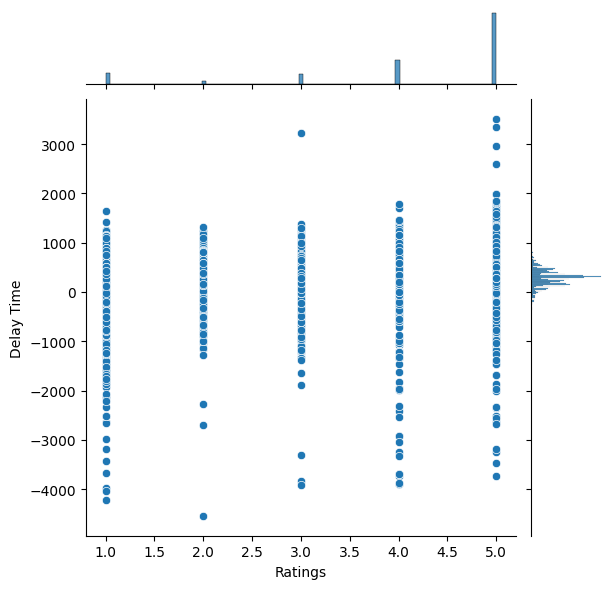

In [39]:
sns.jointplot(y='estimate_actual_diff', x='Review_score', data = df, kind = 'scatter')
plt.xlabel('Ratings')
plt.ylabel('Delay Time')

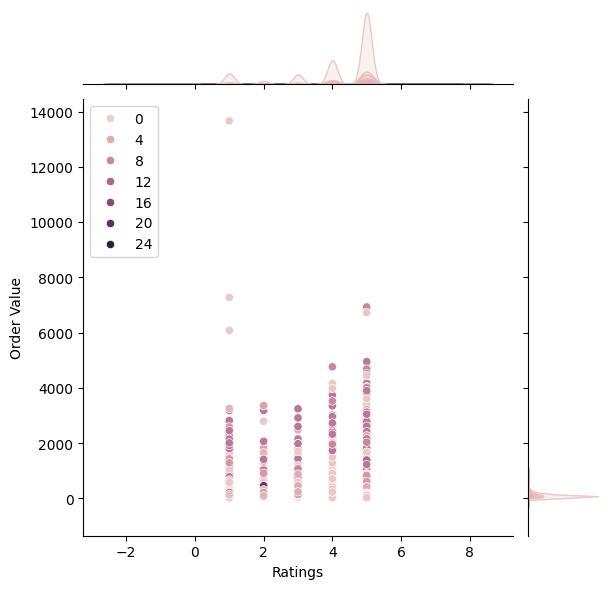

In [40]:
sns.jointplot(y='Payment_value', x = 'Review_score', data =df, kind = 'scatter', hue ='Payment_installments')
plt.xlabel('Ratings')
plt.ylabel('Order Value')
plt.legend(loc='upper left')

<Axes: >

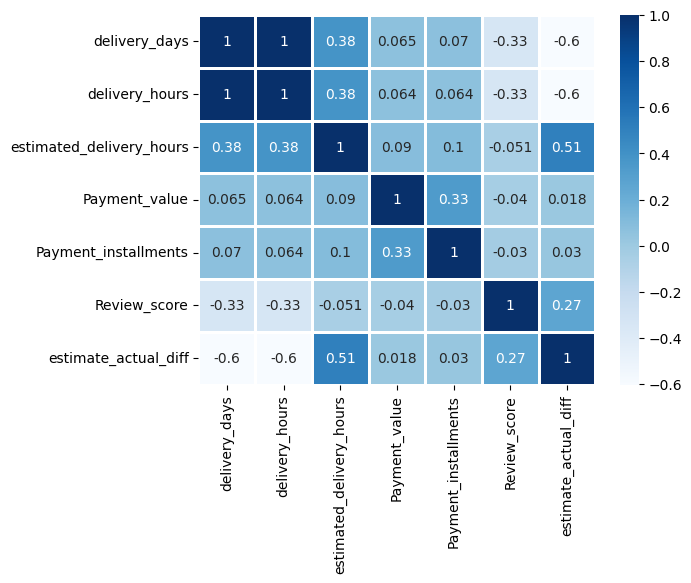

In [41]:
corr_matrix = df.corr(numeric_only = True)
sns.heatmap(corr_matrix, cmap = 'Blues', linecolor = 'white', linewidth = 1, annot = True)

## PHASE 8 - SELLER ANALYSIS 

In [42]:
query = '''SELECT OI.seller_id as seller_id,
OI.order_id AS order_id, 
OI.order_item_id as order_item_id,
OP.payment_sequential as payment_sequential,
OP.payment_value as seller_revenue
FROM order_items OI
JOIN order_payment OP
ON OI.order_id = OP.order_id
JOIN orders O 
on OP.order_id = O.order_id
where O.order_status = 'delivered';'''

seller_df = pd.read_sql(query,engine)
seller_df.duplicated().sum()
seller_orders = seller_df.groupby('seller_id')['order_id'].nunique()
print(seller_orders.sort_values(ascending=False))

seller_rev = seller_df.groupby('seller_id')['seller_revenue'].sum()
total_revenue = seller_rev.sum()
# print(total_revenue)
seller_rev.sort_values(ascending = False, inplace = True)
seller_rev = seller_rev.to_frame(name='Revenue')
seller_rev["Revenue Contribution"] = round(seller_rev["Revenue"]/ total_revenue*100,3)
seller_rev['Cumulative Percentage'] = seller_rev["Revenue Contribution"].cumsum()
# seller_rev = seller_rev.merge(
#     seller_info,
#     on='seller_id',
#     how='left')
seller_rev = seller_rev.merge(
    seller_orders, 
    on = 'seller_id',
    how = 'left'
)
seller_rev.rename(columns = {'order_id' : 'Order Counts'}, inplace = True)
seller_rev.head()
total_orders = seller_rev['Order Counts'].sum()
seller_rev['Order Percentage'] = round(seller_rev["Order Counts"]/total_orders*100,2)
top20 = seller_rev[seller_rev['Cumulative Percentage'] <= 20]
top20_order_perc = top20['Order Percentage'].sum()
# print(top20_order_perc)
top20
top_threshold = round(seller_rev['Revenue'].quantile(0.80),2)
average_threshold = round(seller_rev['Revenue'].quantile(0.30),2)
top_sellers = seller_rev[seller_rev['Revenue'] >= top_threshold]
average_sellers = seller_rev[(seller_rev['Revenue'] > average_threshold) & (seller_rev['Revenue'] < top_threshold)]
print(f"Top sellers revenue percentage contributtion : {top_sellers['Revenue Contribution'].sum()}")
print(f"Average sellers revenue percentage contributtion : {round(average_sellers['Revenue Contribution'].sum(),3)}")
print(f"Top sellers order percentage contributtion : {round(top_sellers['Order Percentage'].sum(),2)}")
print(f"Average sellers order percentage contributtion : {round(average_sellers['Order Percentage'].sum(),3)}")
# print(top_sellers['seller_state'].value_counts())
# print(average_sellers['seller_state'].value_counts())
seller_rev.to_csv("Seller_analysis.csv", index = True)
seller_rev



seller_id
6560211a19b47992c3666cc44a7e94c0    1819
4a3ca9315b744ce9f8e9374361493884    1772
cc419e0650a3c5ba77189a1882b7556a    1651
1f50f920176fa81dab994f9023523100    1399
da8622b14eb17ae2831f4ac5b9dab84a    1311
                                    ... 
028872bfa080090a9d0abd4f1af168f8       1
0936e1837d0c79253456bbb2ffaaef10       1
0b1ca3ef18a63d7eb0c8897fa0849c08       1
0b09101900100c0e9d312861fad5a1b9       1
0af2ab31141893d26aca5a404a537dab       1
Name: order_id, Length: 2970, dtype: int64
Top sellers revenue percentage contributtion : 82.006
Average sellers revenue percentage contributtion : 17.1
Top sellers order percentage contributtion : 77.76
Average sellers order percentage contributtion : 20.44


,Revenue,Revenue Contribution,Cumulative Percentage,Order Counts,Order Percentage
seller_id,,,,,
7c67e1448b00f6e969d365cea6b010ab,505437.16,2.556,2.556,973,0.99
1025f0e2d44d7041d6cf58b6550e0bfa,306000.35,1.547,4.103,910,0.93
4a3ca9315b744ce9f8e9374361493884,295830.76,1.496,5.599,1772,1.81
1f50f920176fa81dab994f9023523100,289861.38,1.466,7.065,1399,1.43
53243585a1d6dc2643021fd1853d8905,279843.42,1.415,8.480,348,0.36
...,...,...,...,...,...
3ac588cd562971392504a9e17130c40b,19.29,0.000,99.958,1,0.00
ad14615bdd492b01b0d97922e87cb87f,19.21,0.000,99.958,1,0.00
702835e4b785b67a084280efca355756,18.56,0.000,99.958,1,0.00


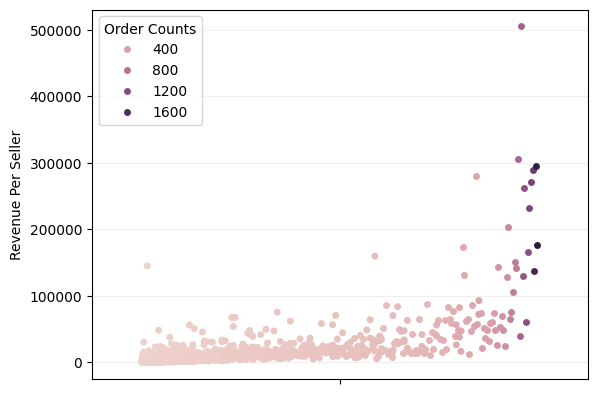

In [43]:
sns.stripplot(y = 'Revenue', data = seller_rev, hue = 'Order Counts', jitter = True, dodge = True)
plt.ylabel('Revenue Per Seller')
plt.grid(axis = 'y', alpha = 0.2 )

Text(0.5, 1.0, 'Revenue Distribution')

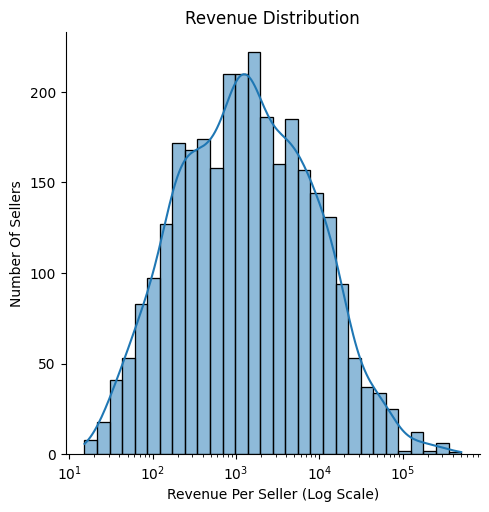

In [44]:
sns.displot(seller_rev["Revenue"], bins = 30, kde = True, log_scale =True)
plt.xlabel('Revenue Per Seller (Log Scale)')
plt.ylabel('Number Of Sellers')
plt.title('Revenue Distribution')

Text(0.5, 1.0, 'Total Orders Distribution')

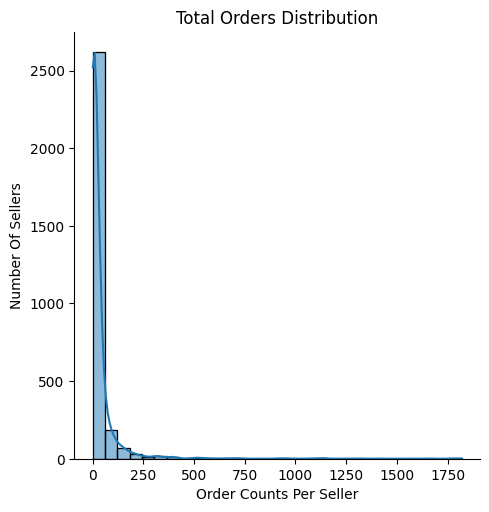

In [45]:
sns.displot(seller_rev['Order Counts'], kde = True, bins = 30)
plt.xlabel('Order Counts Per Seller')
plt.ylabel('Number Of Sellers')
plt.title('Total Orders Distribution')

1. Out of 3095 total sellers 18 sellers contribute 20 % of the total revenue and 17.74 % of the total orders, and 136 sellers contribute 50 % of the total revenue and 45.24 % of the total orders, rest 50 % revenue and 54.76 % orders comes from the remaining 2903 sellers.
2. Out of the 18 top sellers 14 are from SP state, 2 from RJ and 1 from MG and BA each.
3. There are a total of 619 sellers that fall into top sellers category i.e. generating more revenue than 80 % of the sellers and 1547 sellers fall are categorized as average sellers (top sellers excluded) generating more revenue than 30 % of the total sellers.
4. The average sellers contribute around 17.084 % to the total revenue and account for 18.99 % of total orders while the  top sellers contribute 81.948 %  to the revenue and 78.45 % to total orders.

In [46]:
query = '''SELECT OI.seller_id , O.order_status AS ORDER_STATUS,
TIMESTAMPDIFF(HOUR, order_approved_at, order_delivered_customer_date) as delivery_hours,
TIMESTAMPDIFF(HOUR, order_approved_at, order_estimated_delivery_date) as estimated_delivery_hours,
TIMESTAMPDIFF(HOUR, order_purchase_timestamp, order_approved_at) as approval_time,
R.review_score as Rating
From order_items OI 
JOIN orders O 
ON OI.order_id = O.order_id
JOIN review R 
ON O.order_id = R.order_id;'''

df = pd.read_sql(query, engine)
df.drop_duplicates(inplace = True)
df.duplicated().sum()
df['delay time'] = df['delivery_hours'] - df['estimated_delivery_hours']
df[df['delivery_hours'].isna()]
# df.info()

fulfilled_orders = df[df['ORDER_STATUS'] == 'delivered']


seller_grp = fulfilled_orders.groupby('seller_id')
seller_delivery = seller_grp.agg(
    avg_delivery_hours = ('delivery_hours', 'mean'),
    avg_approval_hours = ('approval_time', 'mean'),
    median_delay_hours = ('delay time', 'median'), 
    avg_delay_hours = ('delay time', 'mean'),
    average_ratings = ('Rating', 'mean'),
    median_ratings = ('Rating', 'median'),
    order_counts = ('ORDER_STATUS', 'count')
)

print('80 Percentile (Avg Delivery Hours): ', seller_delivery['avg_delay_hours'].quantile(0.80))
print('25 Percentile(Avg ratings): ', seller_delivery['average_ratings'].quantile(0.25))
print('50 Percentile (Order Counts): ', seller_delivery['order_counts'].quantile(0.50))

delay_sellers = seller_delivery[(seller_delivery['avg_delay_hours'] > -182.27) & (seller_delivery['order_counts'] >= 7)] # I have taken the threshold for delay sellers to be -182.27 hours as 80% of sellers have less than -182.27 avg delay hours and total orders as 7 because 50% of sellers have orders less than 7

low_rated_sellers = seller_delivery[(seller_delivery['average_ratings'] <= 3.96) & (seller_delivery['order_counts'] >= 7)] # I have taken rating for low rated orders to be 3.96 as 25% of sellers have less than 3.96 ratings

# top_30_delay = delay_sellers.sort_values(by= 'avg_delay_hours', ascending = False).head(30)
# top_30_delay

# top_30_low = low_rated_sellers.sort_values(by= 'average_ratings', ascending = True).head(30)
# top_30_low
# sns.boxplot(y = 'mean_delivery_hours', data = seller_delivery)



80 Percentile (Avg Delivery Hours):  -182.2666666666666
25 Percentile(Avg ratings):  3.967741935483871
50 Percentile (Order Counts):  7.0


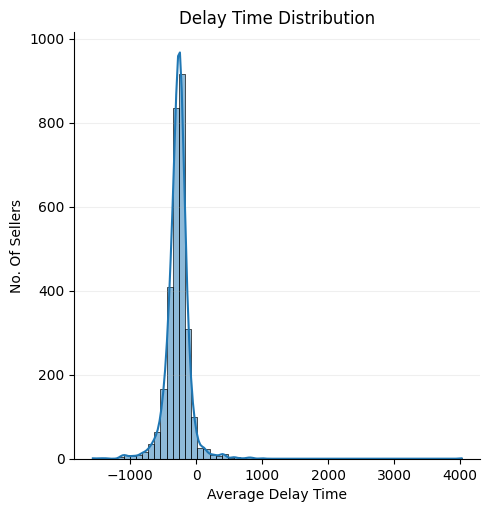

In [47]:
sns.displot(seller_delivery['avg_delay_hours'], kde = True, bins = 60)
plt.ylabel('No. Of Sellers')
plt.xlabel('Average Delay Time')
plt.title('Delay Time Distribution')
plt.grid(axis = 'y', alpha = 0.2)

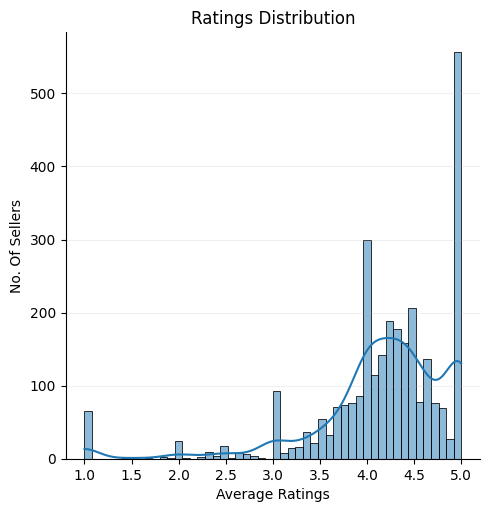

In [48]:
sns.displot(seller_delivery['average_ratings'], kde = True, bins = 50)
plt.ylabel('No. Of Sellers')
plt.xlabel('Average Ratings')
plt.title('Ratings Distribution')
plt.grid(axis = 'y', alpha = 0.2)

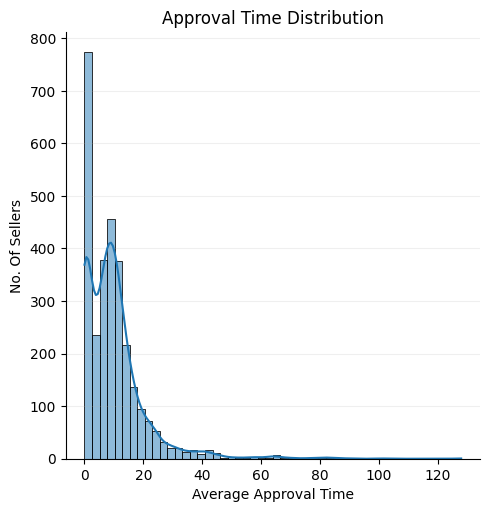

In [49]:
sns.displot(seller_delivery['avg_approval_hours'], kde = True, bins = 50)
plt.ylabel('No. Of Sellers')
plt.xlabel('Average Approval Time')
plt.title('Approval Time Distribution')
plt.grid(axis = 'y', alpha = 0.2)

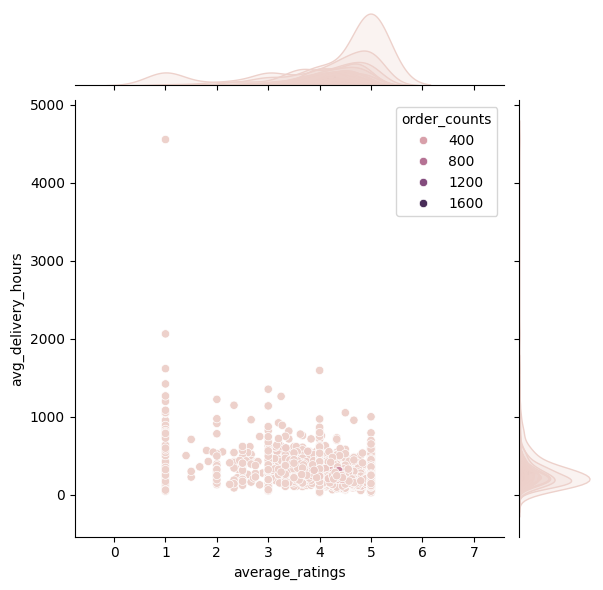

In [50]:
sns.jointplot(y = 'avg_delivery_hours', x = 'average_ratings',hue = 'order_counts', data =seller_delivery, kind = 'scatter')

<Axes: >

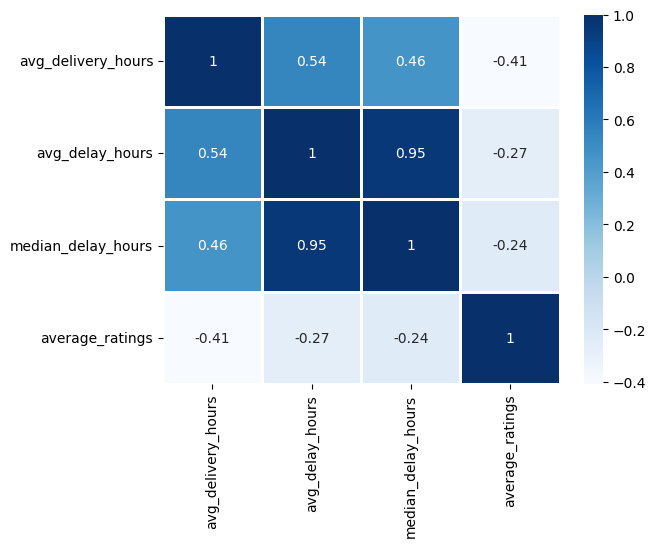

In [51]:
delivery_rating_corr = seller_delivery[
    ['avg_delivery_hours',
     'avg_delay_hours',
     'median_delay_hours',
    'average_ratings']].corr()

sns.heatmap(delivery_rating_corr, annot = True, cmap = 'Blues', linewidth = 1)


1. There are a total of 363 sellers who are categorized as low rated, i.e. having an average rating less than 3.96 and more than 7 fulfilled orders.
2. There are 179 sellers that fall under sellers with delay, i.e. who deliver in less than -182.27 hours of the estimated delivery time on average, and have more than 7 fulfilled orders.
3. The top 30 low rated sellers have avg rating less than 3.2 and 23 of them have median rating 3.5 or less, 18 of them also fall in sellers with delay category and almost 20 of them take almost or more than 24 hours to approve an order showing a strong relationship of bad ratings with high approval time and delay time.
4. The top 30 with most delay have avg delay hours more than -92 hours and 25 of them have median more than -182 which is the threshold, 22 of them also fall in low rated sellers category but only 12 - 13 of have more than 24 hours approval time, showing a strong relationship of sellers with delay with low rating but not with approval time.

## PHASE 9 - PARETO ANALYSIS

In [52]:
query = '''SELECT OI.seller_id AS seller_id,
OI.order_id AS order_id, 
OI.order_item_id as order_item_id,
OP.payment_sequential as payment_sequential,
OP.payment_value as payment_value
FROM order_items OI
JOIN order_payment OP
ON OI.order_id = OP.order_id
JOIN orders O 
ON OI.order_id = O.order_id
WHERE O.order_status = 'delivered';'''

df = pd.read_sql(query,engine)

df.duplicated().sum()

seller_grp = df.groupby('seller_id')
seller_stats = seller_grp.agg(
    Seller_Revenue = ('payment_value', 'sum'),
    Order_counts = ('order_id', 'nunique')
)
total_revenue = seller_stats['Seller_Revenue'].sum()
total_orders = seller_stats['Order_counts'].sum()
print('Total Revenue : ', total_revenue)
print('Total Orders : ', total_orders)


seller_stats['Revenue Perc'] = round(seller_stats["Seller_Revenue"]/total_revenue*100,3)
seller_stats['Order Perc'] = round(seller_stats["Order_counts"]/total_orders*100,3)
seller_stats.sort_values(by = 'Seller_Revenue', ascending = False, inplace = True)
seller_stats['Cumulative Rev Perc'] = seller_stats['Revenue Perc'].cumsum()
seller_stats.reset_index(inplace=True)
# seller_stats.info()
no_of_sellers_in20 = 0.2*2970
no_of_sellers_in20
top_20_sellers = seller_stats[seller_stats.index < 594]

top_20_sellers_rev = top_20_sellers['Seller_Revenue'].sum()
top_20_sellers_ord = top_20_sellers['Order_counts'].sum()
top_20_sellers_rev_perc = top_20_sellers_rev/total_revenue*100
top_20_sellers_ord_perc = top_20_sellers_ord/total_orders*100

print('Revenue by top 20 % sellers Revenue wise', top_20_sellers_rev)
print('Revenue Percentage by top 20 % sellers Revenue wise', round(top_20_sellers_rev_perc,2))
print('Total Orders by top 20 % sellers Revenue wise', top_20_sellers_ord)
print('Total Orders Percentage by top 20 % sellers Revenue wise', round(top_20_sellers_ord_perc,2))

print('Revenue by top 20 % sellers Total Order wise', top_20_sellers_rev)
print('Revenue Percentage by top 20 % sellers Total Order wise', round(top_20_sellers_rev_perc,2))
print('Total Orders by top 20 % sellers Total Order wise', top_20_sellers_ord)
print('Total Orders Percentage by top 20 % sellers Total Order wise', round(top_20_sellers_ord_perc,2))

top_20_sellers['Cumulative Ord Perc'] = top_20_sellers['Order Perc'].cumsum()
seller_stats
revenue_order_corr = seller_stats['Seller_Revenue'].corr(seller_stats['Order_counts'])
print(revenue_order_corr)
top_20_sellers.to_csv("top20%sellers.csv", index = True)

Total Revenue :  19776160.44
Total Orders :  97818
0.8123302504297504


C:\Users\Nikhil\AppData\Local\Temp\ipykernel_17980\1814184089.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_20_sellers['Cumulative Ord Perc'] = top_20_sellers['Order Perc'].cumsum()


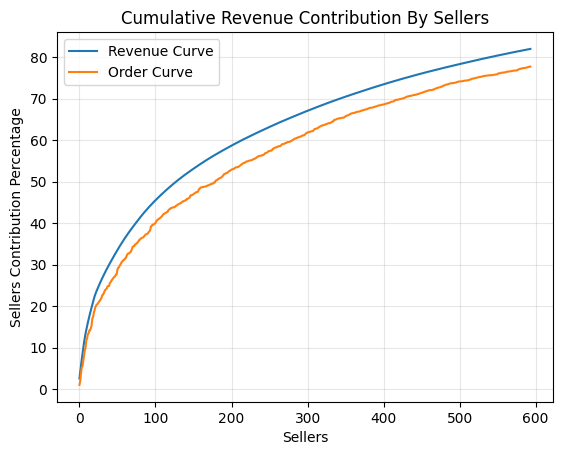

In [53]:
plt.plot(top_20_sellers['Cumulative Rev Perc'], label = 'Revenue Curve')
plt.plot(top_20_sellers['Cumulative Ord Perc'], label = 'Order Curve')
plt.ylabel('Sellers Contribution Percentage')
plt.xlabel("Sellers")
plt.title('Cumulative Revenue Contribution By Sellers')
plt.grid(alpha = 0.3)
plt.legend()
plt.show()

In [54]:
query = '''SELECT C.customer_unique_id as customer_unq_id,
SUM(OP.payment_value) as payment_value, 
COUNT(DISTINCT(O.order_id)) AS order_counts
FROM customers C 
JOIN orders O 
ON C.customer_id = O.customer_id 
JOIN order_payment OP
ON O.order_id =  OP.order_id
WHERE O.order_status = 'delivered'
GROUP BY C.customer_unique_id
Order by payment_value desc
LIMIT 19220;'''

total_orders = 96477

df = pd.read_sql(query, engine)
df['rev_contri_perc'] = df['payment_value']/total_revenue*100
df['cumulative_perc'] = df['rev_contri_perc'].cumsum()
top_20_rev = df['payment_value'].sum()
top_20_rev_perc = top_20_rev/total_revenue*100
top_20_ord = df['order_counts'].sum()
top_20_ord_perc = top_20_ord/total_orders*100
print("Revenue by top 20 % customers", round(top_20_rev,3))
print("Revenue percentage by top 20 % customers", round(top_20_rev_perc,3))
print("Orders by top 20 % customers", top_20_ord)
print("Orders percentage by top 20 % customers", round(top_20_ord_perc,3))
df.head()


Revenue by top 20 % customers 8368268.79
Revenue percentage by top 20 % customers 42.315
Orders by top 20 % customers 21043
Orders percentage by top 20 % customers 21.811


,customer_unq_id,payment_value,order_counts,rev_contri_perc,cumulative_perc
0,0a0a92112bd4c708ca5fde585afaa872,13664.08,1,0.069094,0.069094
1,da122df9eeddfedc1dc1f5349a1a690c,7571.63,2,0.038287,0.107380
2,763c8b1c9c68a0229c42c9fc6f662b93,7274.88,1,0.036786,0.144166
3,dc4802a71eae9be1dd28f5d788ceb526,6929.31,1,0.035039,0.179205
4,459bef486812aa25204be022145caa62,6922.21,1,0.035003,0.214208


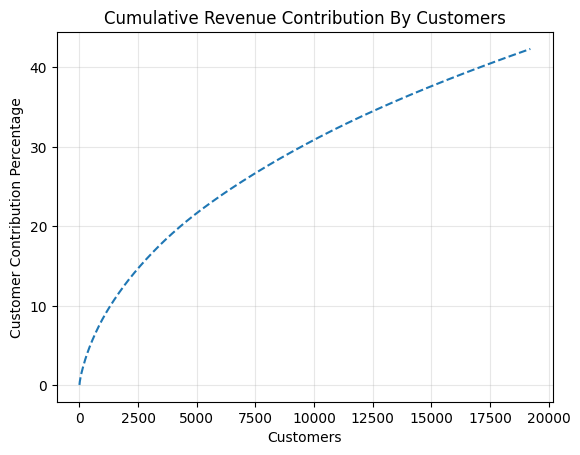

In [55]:
plt.plot(df['cumulative_perc'], linestyle = '--' )
plt.ylabel('Customer Contribution Percentage')
plt.xlabel("Customers")
plt.title('Cumulative Revenue Contribution By Customers')
plt.grid(alpha = 0.3)
plt.show()

1. Top 20 % sellers revenue wise contribute 16219003.32 to the total revenue which makes up 82.01 % of the total revenue and account for 76060 orders which is 77.76 % of the total orders.
2. Top 20 % sellers Total Orders wise contribute 15011340.51 to the total revenue which makes up 75.91 % of the total revenue and account for 80644 orders which is 82.44 % of the total orders.
3. Top 20 % customers contribute 8368286.79 to the total revenue which makes up 42.315 % of the total revenue and account for 21043 orders which is 21.811 % of the total orders.

## PHASE 10 - CORRELATION ANALYSIS

0.81


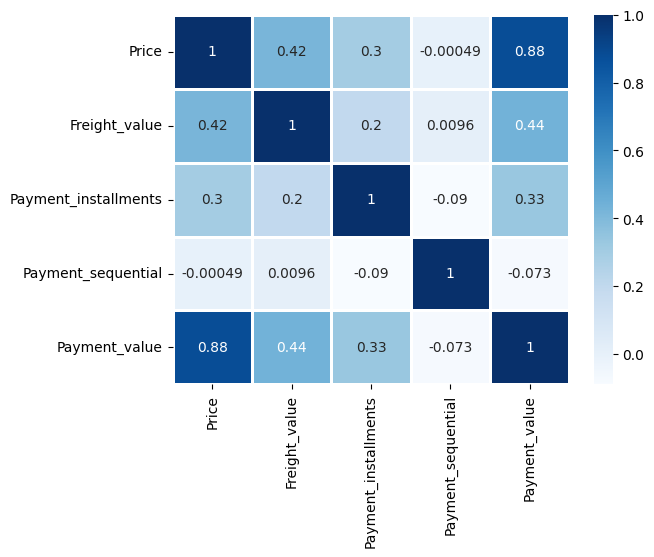

In [56]:
query = '''SELECT OP.order_id as order_id, OI.price as Price,
 OI.freight_value as Freight_value,
OP.payment_installments as Payment_installments,
OP.payment_sequential as Payment_sequential,
 OP.payment_value as Payment_value
FROM order_payment OP
JOIN order_items OI
ON OP.order_id = OI.order_id
JOIN orders O
on OI.order_id = O.order_id
where O.order_status = 'delivered';'''

df = pd.read_sql(query, engine);
df.drop_duplicates(inplace = True)
# df[df.duplicated(subset = 'order_id')]


corr_matrix = df.corr(numeric_only = True)
sns.heatmap(corr_matrix, annot = True, cmap = 'Blues', linewidth = 1)

revenue_order_corr = seller_stats['Seller_Revenue'].corr(seller_stats['Order_counts'])
print(round(revenue_order_corr,2))


1. Frieght value and Price of product are moderately related (0.42) suggesting that expensive items often come with high freight charges which is quite understandable because it requires more care, a similar relationship is also seen in between freight value and payment value (r=0.44).
2. Price and payment installments also show a low to moderate positive relationship (r = 0.3) which means that people tend to pay in more number of installments when the price of product is high and a similar relationship (r = 0.33) is seen between payment value and installments.
3. Seller revenue and Order counts show a strong positive relationship (r = 0.81) which shows that high order volume results in higher revenue for the sellers.

<Axes: >

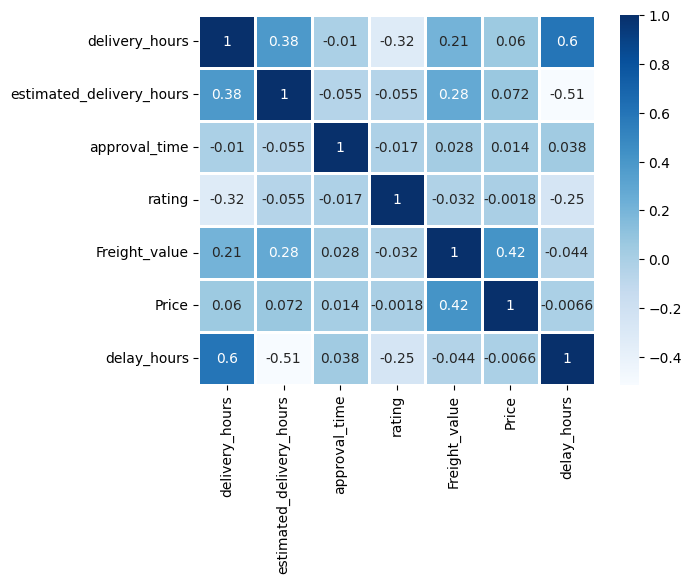

In [57]:
query = '''SELECT O.order_id as order_id,
TIMESTAMPDIFF(HOUR, order_approved_at, order_delivered_customer_date) as delivery_hours,
TIMESTAMPDIFF(HOUR, order_approved_at, order_estimated_delivery_date) as estimated_delivery_hours,
TIMESTAMPDIFF(HOUR, order_purchase_timestamp, order_approved_at) as approval_time,
R.review_score AS rating,
OI.freight_value as Freight_value,
OI.price as Price
FROM orders O 
JOIN review R
ON O.order_id = R.order_id
JOIN order_items OI
ON O.order_id = OI.order_id
WHERE O.order_status = 'delivered';'''

df = pd.read_sql(query, engine)
df.drop_duplicates(inplace = True)
# df[df.duplicated()]
df['delay_hours'] = df['delivery_hours'] - df['estimated_delivery_hours']

corr_matrix = df.corr(numeric_only = True)
sns.heatmap(corr_matrix, annot = True, cmap = 'Blues', linewidth = 1)


1. Delivery hours are strong to moderately associated with delay hours (r = 0.60) that means the delay is supposedly more in longer deliveries which makes sense because longer deliveries have room for delays.
2. Longer delivery times are moderately associated with lower customer ratings (r = -0.32), suggesting that improving delivery speed could positively influence customer satisfaction.
3. Delays in delivery also influence reviews (r = -0.25), but this relationship is less stronger than delivery hours and ratings, which suggests that customers get frustrated more when the overall delivery time is longer, than when their order is delivered late.
4. Estimated delivery hours are negatively associated with delay time (r = -0.51) which suggests that there are less chances of delays when the estimates delivery time is more meaning sellers perform better when they have a good buffer in estimated delivery time.
5. Estimated delivery hours and delivery hours have a moderately strong relationship (r = 0.38) which suggests that delivery takes longer  time when the estimated delivery time is more.
6. Product price and Freight value shows virtually no correlation with customer ratings, suggesting customer satisfaction is driven more by fulfillment performance than product price.


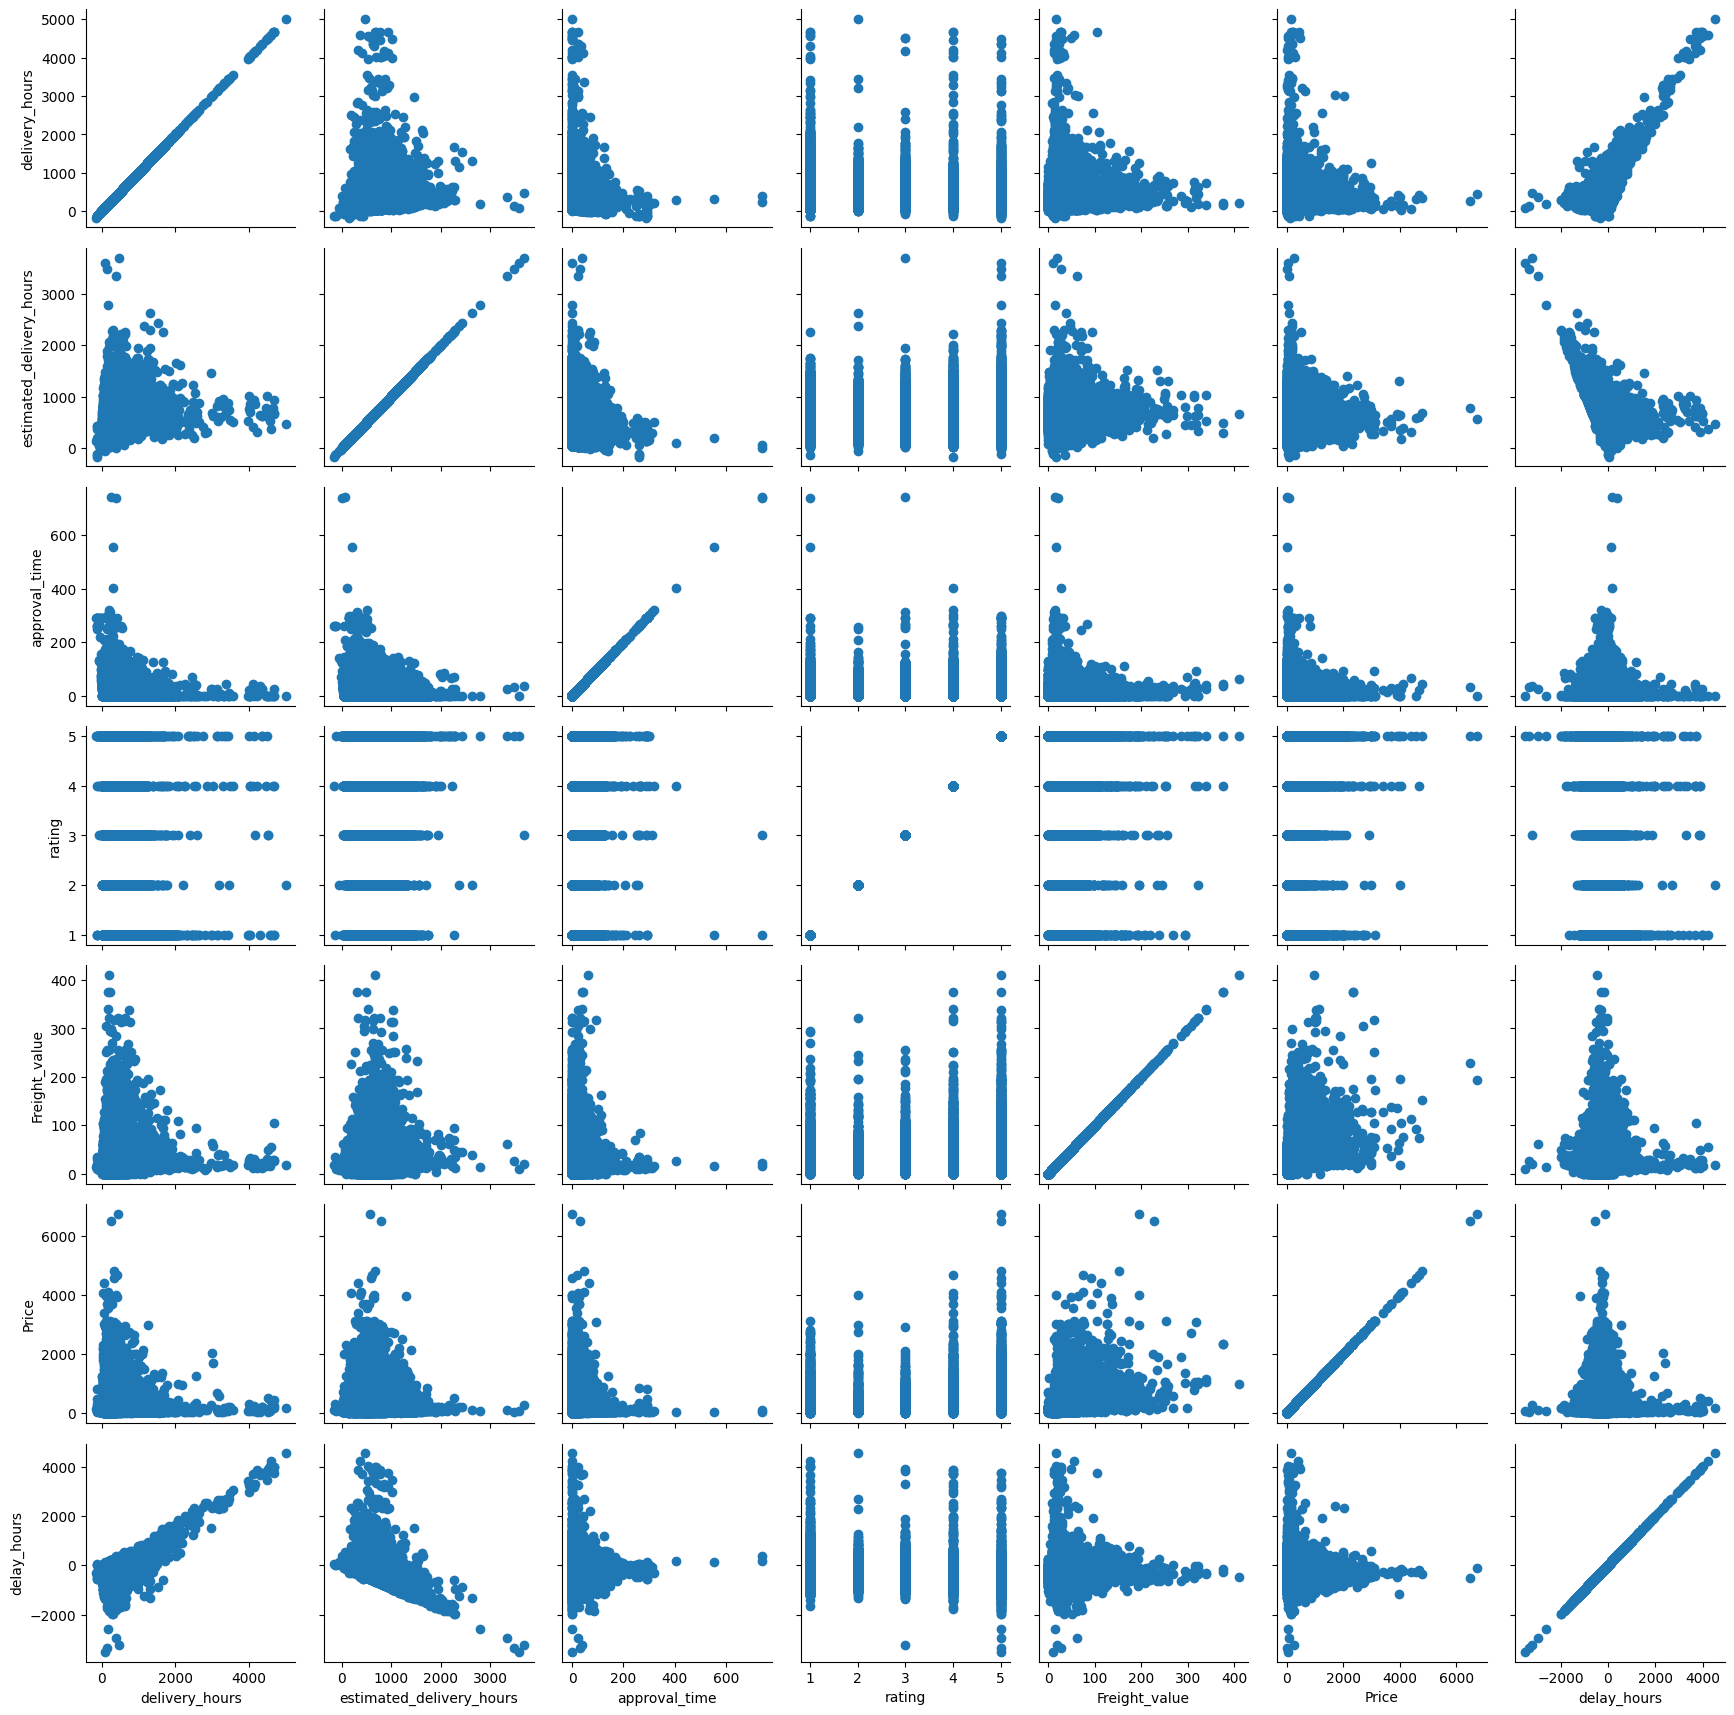

In [58]:
corr_g = sns.PairGrid(df)
corr_g.map(plt.scatter)